<a href="https://colab.research.google.com/github/Tazin17/pain-intensity-prediction-from-laser-evoked-eeg-responses/blob/main/v2_pipeline_of_exp8_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from google.colab import drive

# Try to unmount if it's already mounted or partially mounted
try:
  drive.flush_and_unmount()
  print('Drive unmounted.')
except ValueError:
  pass # Drive was not mounted, nothing to unmount

# Ensure the mount point is clean
if os.path.isdir('/content/drive'):
  # Remove all contents of the directory, but not the directory itself
  # This avoids issues if the directory is still seen as a mount point
  for item in os.listdir('/content/drive'):
    item_path = os.path.join('/content/drive', item)
    if os.path.isfile(item_path):
      os.remove(item_path)
    elif os.path.isdir(item_path):
      import shutil
      shutil.rmtree(item_path)
  print('Cleared /content/drive directory.')
else:
  # If the directory doesn't exist, create it
  os.makedirs('/content/drive', exist_ok=True)
  print('Created /content/drive directory.')

# Attempt to mount again
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.
Created /content/drive directory.
Mounted at /content/drive


In [ ]:
!pip -q install pymatreader mne scipy scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 19.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# CELL 2 — Imports and paths

import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pymatreader import read_mat
from scipy.signal import welch
from scipy.stats import skew, kurtosis

EXP_NAME = "EXP8"

# Change this path if your Exp8 folder name is different
EXP8_ROOT = "/content/drive/MyDrive/my dataset_raw_main_exp8"

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
os.makedirs(OUT_DIR, exist_ok=True)

print("EXP8_ROOT exists:", os.path.exists(EXP8_ROOT))
print("OUT_DIR:", OUT_DIR)

EXP8_ROOT exists: True
OUT_DIR: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH


In [ ]:
# CELL 3 — Find Exp8 rerefer .set files

candidate_dirs = [
    "/content/exp8_rerefer",
    os.path.join(EXP8_ROOT, "derivatives", "rerefer"),
    os.path.join(EXP8_ROOT, "derivatives-rerefer"),
    os.path.join(EXP8_ROOT, "rerefer"),
]

REREFER_DIR = None
set_files = []

for d in candidate_dirs:
    files = sorted(glob.glob(os.path.join(d, "*.set")))
    if len(files) > 0:
        REREFER_DIR = d
        set_files = files
        break

if len(set_files) == 0 and os.path.exists(EXP8_ROOT):
    all_set_files = sorted(glob.glob(os.path.join(EXP8_ROOT, "**", "*.set"), recursive=True))
    rerefer_files = [f for f in all_set_files if "rerefer" in f.lower()]
    set_files = sorted(rerefer_files if len(rerefer_files) > 0 else all_set_files)
    if len(set_files) > 0:
        REREFER_DIR = os.path.dirname(set_files[0])

print("REREFER_DIR:", REREFER_DIR)
print("Number of .set files:", len(set_files))

if len(set_files) == 0:
    raise FileNotFoundError("No Exp8 .set files found. Check EXP8_ROOT.")

print("First 5 files:")
for f in set_files[:5]:
    print(f)

REREFER_DIR: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer
Number of .set files: 223
First 5 files:
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-002_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-003_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-004_223ByBP.set
/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-005_223ByBP.set


In [ ]:
# CELL 4 — Helper functions

def safe_scalar(x):
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        return safe_scalar(x.flatten()[0])
    if isinstance(x, list):
        if len(x) == 0:
            return np.nan
        return safe_scalar(x[0])
    return x

def get_subject_id(path):
    return os.path.basename(path).split("_")[0]

def clean_channel_name(ch):
    return str(ch).replace(" ", "").replace("-", "").replace(".", "").replace("'", "").replace('"', "")

def get_channel_labels(chanlocs, nbchan=None):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [str(x) for x in chanlocs["labels"]]

    elif isinstance(chanlocs, list):
        for ch in chanlocs:
            if isinstance(ch, dict) and "labels" in ch:
                labels.append(str(safe_scalar(ch["labels"])))

    labels = [clean_channel_name(x) for x in labels if str(x).strip() != ""]

    if nbchan is not None and len(labels) != nbchan:
        labels = [f"Ch{i+1:03d}" for i in range(nbchan)]

    return labels

def listify(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return list(x.flatten())
    return [x]

def get_times_ms(mat):
    if "times" in mat:
        times = np.array(mat["times"], dtype=float).flatten()
        if np.nanmax(np.abs(times)) < 20:
            times = times * 1000
        return times

    pnts = int(safe_scalar(mat["pnts"]))
    xmin = float(safe_scalar(mat.get("xmin", -1)))
    xmax = float(safe_scalar(mat.get("xmax", 2)))
    return np.linspace(xmin * 1000, xmax * 1000, pnts)

def load_eeg_data_from_set(mat, set_path, rerefer_dir):
    data = mat["data"]

    if isinstance(data, str):
        datfile = str(safe_scalar(mat.get("datfile", "")))

        if datfile == "" or datfile.lower() == "nan":
            datfile = os.path.splitext(os.path.basename(set_path))[0] + ".fdt"

        fdt_path = os.path.join(rerefer_dir, datfile)

        if not os.path.exists(fdt_path):
            fdt_path = os.path.join(os.path.dirname(set_path), datfile)

        if not os.path.exists(fdt_path):
            raise FileNotFoundError(f"Missing .fdt file: {fdt_path}")

        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))

        raw = np.fromfile(fdt_path, dtype=np.float32)
        data = raw.reshape((nbchan, pnts, trials), order="F")

    else:
        data = np.array(data)

    if data.ndim == 2:
        nbchan = int(safe_scalar(mat["nbchan"]))
        pnts = int(safe_scalar(mat["pnts"]))
        trials = int(safe_scalar(mat["trials"]))
        data = data.reshape((nbchan, pnts, trials), order="F")

    return data

def extract_trial_metadata_from_epoch(mat, n_trials):
    pain = [np.nan] * n_trials
    laser = [np.nan] * n_trials
    etype = [np.nan] * n_trials

    epoch = mat.get("epoch", None)

    pain_keys = ["eventrating", "rating", "painrating", "eventpainrating", "eventNRS", "NRS"]
    laser_keys = ["eventlaser_power", "laser_power", "laserpower", "eventlaserpower", "eventLaserPower"]
    type_keys = ["eventtype", "type"]

    if isinstance(epoch, list):
        for i in range(min(len(epoch), n_trials)):
            ep = epoch[i]
            if isinstance(ep, dict):
                for key in pain_keys:
                    if key in ep:
                        pain[i] = safe_scalar(ep[key])
                        break
                for key in laser_keys:
                    if key in ep:
                        laser[i] = safe_scalar(ep[key])
                        break
                for key in type_keys:
                    if key in ep:
                        etype[i] = safe_scalar(ep[key])
                        break

    elif isinstance(epoch, dict):
        for key in pain_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    pain[i] = safe_scalar(vals[i])
                break

        for key in laser_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    laser[i] = safe_scalar(vals[i])
                break

        for key in type_keys:
            if key in epoch:
                vals = listify(epoch[key])
                for i in range(min(len(vals), n_trials)):
                    etype[i] = safe_scalar(vals[i])
                break

    return pain, laser, etype

In [ ]:
# CELL 5 — Inspect all .set files: subjects, channels, epochs

inventory_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Inspecting .set files"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)

        inventory_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "nbchan": int(safe_scalar(mat.get("nbchan", np.nan))),
            "pnts": int(safe_scalar(mat.get("pnts", np.nan))),
            "trials_epochs": int(safe_scalar(mat.get("trials", np.nan))),
            "srate": float(safe_scalar(mat.get("srate", np.nan))),
            "xmin_sec": float(safe_scalar(mat.get("xmin", np.nan))),
            "xmax_sec": float(safe_scalar(mat.get("xmax", np.nan))),
        })

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

inventory_df = pd.DataFrame(inventory_rows)
failed_df = pd.DataFrame(failed_rows)

inventory_path = os.path.join(OUT_DIR, "exp8_inventory_epoch_counts.csv")
failed_path = os.path.join(OUT_DIR, "exp8_inventory_failed_files.csv")

inventory_df.to_csv(inventory_path, index=False)
failed_df.to_csv(failed_path, index=False)

print("Subjects/files inspected:", len(inventory_df))
print("Failed files:", len(failed_df))

print("\nTrial/epoch count distribution:")
display(inventory_df["trials_epochs"].value_counts().sort_index())

print("\nTotal retained epochs after preprocessing:")
print(int(inventory_df["trials_epochs"].sum()))

print("\nTheoretical maximum:")
print("223 subjects × 30 trials = 6690 epochs")

display(inventory_df.head())

Inspecting .set files: 100%|██████████| 223/223 [00:48<00:00,  4.62it/s]


Subjects/files inspected: 223
Failed files: 0

Trial/epoch count distribution:


,count
trials_epochs,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16



Total retained epochs after preprocessing:
6275

Theoretical maximum:
223 subjects × 30 trials = 6690 epochs


,subject_id,file,nbchan,pnts,trials_epochs,srate,xmin_sec,xmax_sec
0,sub-001,sub-001_223ByBP.set,64,3000,28,1000.0,-1.0,1.999
1,sub-002,sub-002_223ByBP.set,64,3000,25,1000.0,-1.0,1.999
2,sub-003,sub-003_223ByBP.set,62,3000,25,1000.0,-1.0,1.999
3,sub-004,sub-004_223ByBP.set,64,3000,27,1000.0,-1.0,1.999
4,sub-005,sub-005_223ByBP.set,64,3000,27,1000.0,-1.0,1.999


In [ ]:
# CELL 6 — Inspect one subject deeply

example_path = set_files[0]
mat = read_mat(example_path)

print("Example file:", example_path)

print("\nBasic shape info:")
for k in ["nbchan", "pnts", "trials", "srate", "xmin", "xmax"]:
    print(k, ":", safe_scalar(mat.get(k, None)))

nbchan = int(safe_scalar(mat["nbchan"]))
labels = get_channel_labels(mat.get("chanlocs", []), nbchan=nbchan)

print("\nNumber of channel labels:", len(labels))
print("First 30 channel labels:")
print(labels[:30])

print("\nEpoch object type:", type(mat.get("epoch", None)))

epoch = mat.get("epoch", None)

if isinstance(epoch, list) and len(epoch) > 0:
    print("\nFirst epoch keys:")
    print(epoch[0].keys() if isinstance(epoch[0], dict) else type(epoch[0]))

elif isinstance(epoch, dict):
    print("\nEpoch dictionary keys:")
    print(epoch.keys())

Example file: /content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer/sub-001_223ByBP.set

Basic shape info:
nbchan : 64
pnts : 3000
trials : 28
srate : 1000
xmin : -1
xmax : 1.999

Number of channel labels: 64
First 30 channel labels:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'FT9', 'FT10']

Epoch object type: <class 'dict'>

Epoch dictionary keys:
dict_keys(['event', 'eventlatency', 'eventduration', 'eventchannel', 'eventbvtime', 'eventbvmknum', 'eventvisible', 'eventtype', 'eventcode', 'eventurevent', 'eventrating', 'eventlaser_power'])


In [ ]:
# CELL 7 — Extract trial metadata and binary labels

metadata_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Extracting metadata"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)
        n_trials = int(safe_scalar(mat["trials"]))

        pain, laser, etype = extract_trial_metadata_from_epoch(mat, n_trials)

        for t in range(n_trials):
            metadata_rows.append({
                "experiment": EXP_NAME,
                "subject_id": sid,
                "trial_num": t + 1,
                "painrating": pain[t],
                "laser_power": laser[t],
                "event_type": etype[t],
                "source_file": os.path.basename(set_path)
            })

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

meta_df = pd.DataFrame(metadata_rows)
failed_meta_df = pd.DataFrame(failed_rows)

meta_df["painrating"] = pd.to_numeric(meta_df["painrating"], errors="coerce")
meta_df["laser_power"] = pd.to_numeric(meta_df["laser_power"], errors="coerce")

# Final binary label:
# NRS 0–4 = low pain, NRS 5–10 = high pain
meta_df["pain_label"] = np.where(meta_df["painrating"] >= 5, 1, 0)
meta_df["pain_class"] = np.where(meta_df["pain_label"] == 1, "high_pain", "low_pain")

meta_path = os.path.join(OUT_DIR, "exp8_trial_metadata_with_binary_labels.csv")
failed_meta_path = os.path.join(OUT_DIR, "exp8_metadata_failed_files.csv")

meta_df.to_csv(meta_path, index=False)
failed_meta_df.to_csv(failed_meta_path, index=False)

print("Metadata shape:", meta_df.shape)
print("Subjects:", meta_df["subject_id"].nunique())
print("Total epochs/trials:", len(meta_df))
print("Missing painrating:", meta_df["painrating"].isna().sum())
print("Missing laser_power:", meta_df["laser_power"].isna().sum())

print("\nPain rating distribution:")
display(meta_df["painrating"].value_counts(dropna=False).sort_index())

print("\nBinary class distribution:")
display(meta_df["pain_class"].value_counts(dropna=False))

print("\nSaved:", meta_path)

Extracting metadata: 100%|██████████| 223/223 [00:06<00:00, 36.06it/s]

Metadata shape: (6275, 9)
Subjects: 223
Total epochs/trials: 6275
Missing painrating: 0
Missing laser_power: 0

Pain rating distribution:


,count
painrating,
0,51
1,207
2,438
3,855
4,1174
5,1012
6,808
7,751
8,502



Binary class distribution:


,count
pain_class,
high_pain,3550
low_pain,2725



Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/exp8_trial_metadata_with_binary_labels.csv


In [ ]:
# CELL 8 — Subject-wise label balance

subject_label_summary = meta_df.groupby("subject_id").agg(
    n_trials=("painrating", "count"),
    pain_min=("painrating", "min"),
    pain_max=("painrating", "max"),
    pain_mean=("painrating", "mean"),
    low_count=("pain_label", lambda x: int((x == 0).sum())),
    high_count=("pain_label", lambda x: int((x == 1).sum())),
).reset_index()

subject_label_summary["has_both_classes"] = (
    (subject_label_summary["low_count"] > 0) &
    (subject_label_summary["high_count"] > 0)
)

summary_path = os.path.join(OUT_DIR, "exp8_subject_label_balance.csv")
subject_label_summary.to_csv(summary_path, index=False)

print("Total subjects:", subject_label_summary.shape[0])
print("Subjects with both classes:", subject_label_summary["has_both_classes"].sum())
print("Subjects with only one class:", (~subject_label_summary["has_both_classes"]).sum())

print("\nTrial count distribution:")
display(subject_label_summary["n_trials"].value_counts().sort_index())

display(subject_label_summary.head(20))

Total subjects: 223
Subjects with both classes: 205
Subjects with only one class: 18

Trial count distribution:


,count
n_trials,
19,2
20,1
21,3
22,1
23,5
24,9
25,12
26,15
27,16


,subject_id,n_trials,pain_min,pain_max,pain_mean,low_count,high_count,has_both_classes
0,sub-001,28,0,7,4.571429,11,17,True
1,sub-002,25,0,6,1.960000,23,2,True
2,sub-003,25,1,9,3.640000,18,7,True
3,sub-004,27,2,8,5.518519,6,21,True
4,sub-005,27,3,6,4.518519,13,14,True
5,sub-006,30,2,6,3.866667,22,8,True
6,sub-007,28,0,7,4.714286,10,18,True
7,sub-008,30,1,6,3.266667,24,6,True
8,sub-009,27,1,6,3.074074,24,3,True
9,sub-010,26,4,9,6.384615,3,23,True


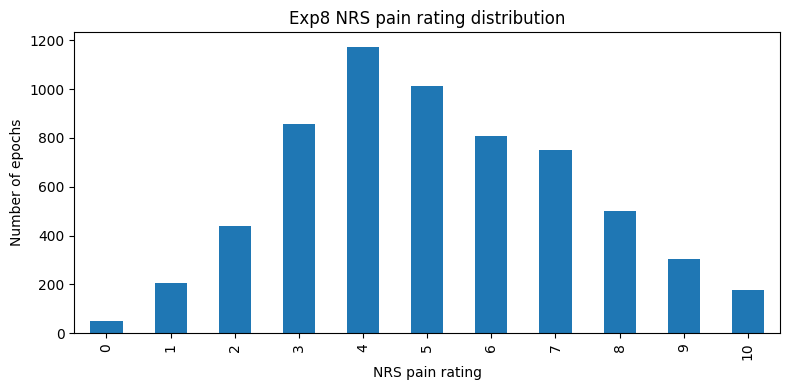

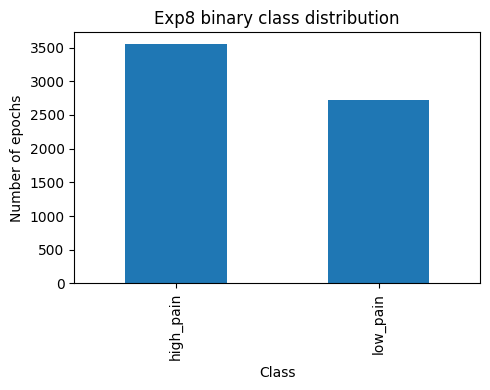

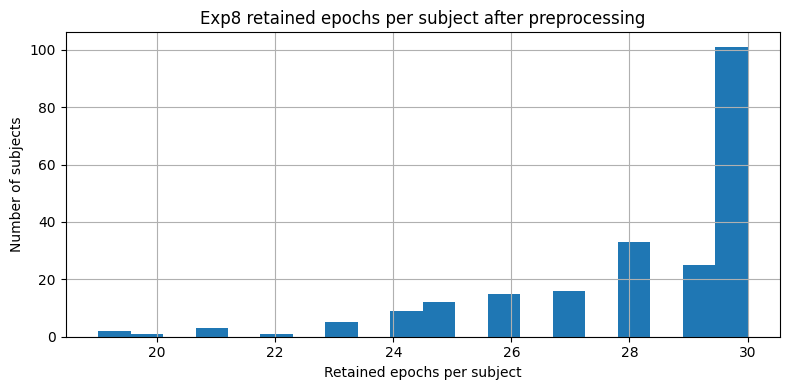

In [ ]:
# CELL 9 — Plot distributions

plt.figure(figsize=(8, 4))
meta_df["painrating"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("NRS pain rating")
plt.ylabel("Number of epochs")
plt.title("Exp8 NRS pain rating distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
meta_df["pain_class"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of epochs")
plt.title("Exp8 binary class distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
subject_label_summary["n_trials"].hist(bins=20)
plt.xlabel("Retained epochs per subject")
plt.ylabel("Number of subjects")
plt.title("Exp8 retained epochs per subject after preprocessing")
plt.tight_layout()
plt.show()

In [ ]:
# CELL 10 — Feature extraction functions

def mean_window(sig, times, a, b):
    idx = np.where((times >= a) & (times <= b))[0]
    if len(idx) == 0:
        return np.nan
    return float(np.nanmean(sig[idx]))

def peak_amp_lat(sig, times, a, b, mode="min"):
    idx = np.where((times >= a) & (times <= b))[0]
    if len(idx) == 0:
        return np.nan, np.nan

    y = sig[idx]
    if np.all(np.isnan(y)):
        return np.nan, np.nan

    k = np.nanargmin(y) if mode == "min" else np.nanargmax(y)
    return float(y[k]), float(times[idx[k]])

def bandpower(sig, fs, fmin, fmax):
    if np.all(np.isnan(sig)):
        return np.nan

    freqs, psd = welch(sig, fs=fs, nperseg=min(512, len(sig)))
    idx = np.where((freqs >= fmin) & (freqs <= fmax))[0]

    if len(idx) == 0:
        return np.nan

    return float(np.trapz(psd[idx], freqs[idx]))

def hjorth_params(sig):
    sig = np.asarray(sig, dtype=float)

    if np.all(np.isnan(sig)):
        return np.nan, np.nan, np.nan

    sig = np.nan_to_num(sig, nan=np.nanmean(sig))

    diff1 = np.diff(sig)
    diff2 = np.diff(diff1)

    var0 = np.var(sig)
    var1 = np.var(diff1)
    var2 = np.var(diff2)

    activity = var0
    mobility = np.sqrt(var1 / var0) if var0 > 0 else np.nan
    complexity = np.sqrt(var2 / var1) / mobility if var1 > 0 and mobility > 0 else np.nan

    return float(activity), float(mobility), float(complexity)

def simple_entropy(sig, bins=20):
    sig = np.asarray(sig, dtype=float)
    sig = sig[~np.isnan(sig)]

    if len(sig) == 0:
        return np.nan

    hist, _ = np.histogram(sig, bins=bins, density=True)
    hist = hist[hist > 0]

    return float(-np.sum(hist * np.log(hist)))

In [ ]:
# CELL 11 — Extract EEG features from Exp8

FEATURE_PATH = os.path.join(OUT_DIR, "exp8_classification_features.csv")
FEATURE_FAILED_PATH = os.path.join(OUT_DIR, "exp8_feature_extraction_failed.csv")

CORE_CHANNELS = [
    "Cz", "FCz", "CPz", "Pz", "Fz",
    "C1", "C2", "FC1", "FC2", "CP1", "CP2"
]

WINDOWS = {
    "early_0_200": (0, 200),
    "n2win_180_350": (180, 350),
    "p2win_300_600": (300, 600),
    "late_600_1000": (600, 1000),
    "global_0_1000": (0, 1000),
}

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 70),
}

feature_rows = []
failed_rows = []

for set_path in tqdm(set_files, desc="Extracting EEG features"):
    sid = get_subject_id(set_path)

    try:
        mat = read_mat(set_path)

        data = load_eeg_data_from_set(mat, set_path, REREFER_DIR)
        times = get_times_ms(mat)

        nbchan = int(safe_scalar(mat["nbchan"]))
        n_trials = int(safe_scalar(mat["trials"]))
        fs = float(safe_scalar(mat.get("srate", 1000)))

        labels = get_channel_labels(mat.get("chanlocs", []), nbchan=nbchan)
        ch_to_idx = {clean_channel_name(ch): i for i, ch in enumerate(labels)}

        selected_channels = [ch for ch in CORE_CHANNELS if clean_channel_name(ch) in ch_to_idx]

        if len(selected_channels) == 0:
            selected_channels = labels[:10]

        pain, laser, etype = extract_trial_metadata_from_epoch(mat, n_trials)

        post_idx = np.where((times >= 0) & (times <= 1000))[0]

        for tr in range(n_trials):
            row = {
                "experiment": EXP_NAME,
                "subject_id": sid,
                "trial_num": tr + 1,
                "painrating": safe_scalar(pain[tr]),
                "laser_power": safe_scalar(laser[tr]),
                "event_type": safe_scalar(etype[tr]),
                "source_file": os.path.basename(set_path)
            }

            selected_sigs = []

            for ch in selected_channels:
                ch_clean = clean_channel_name(ch)
                ci = ch_to_idx[ch_clean]

                sig = data[ci, :, tr].astype(float)
                selected_sigs.append(sig)

                for wname, (a, b) in WINDOWS.items():
                    row[f"{ch_clean}__{wname}_mean"] = mean_window(sig, times, a, b)

                n2_amp, n2_lat = peak_amp_lat(sig, times, 180, 350, mode="min")
                p2_amp, p2_lat = peak_amp_lat(sig, times, 300, 600, mode="max")

                row[f"{ch_clean}__n2_amp"] = n2_amp
                row[f"{ch_clean}__n2_lat"] = n2_lat
                row[f"{ch_clean}__p2_amp"] = p2_amp
                row[f"{ch_clean}__p2_lat"] = p2_lat
                row[f"{ch_clean}__n2p2_amp"] = (
                    p2_amp - n2_amp if pd.notna(p2_amp) and pd.notna(n2_amp) else np.nan
                )

                post_sig = sig[post_idx]

                for bname, (fmin, fmax) in BANDS.items():
                    row[f"{ch_clean}__bp_{bname}"] = bandpower(post_sig, fs, fmin, fmax)

                act, mob, comp = hjorth_params(post_sig)
                row[f"{ch_clean}__hjorth_activity"] = act
                row[f"{ch_clean}__hjorth_mobility"] = mob
                row[f"{ch_clean}__hjorth_complexity"] = comp
                row[f"{ch_clean}__entropy"] = simple_entropy(post_sig)
                row[f"{ch_clean}__std"] = float(np.nanstd(post_sig))
                row[f"{ch_clean}__skew"] = float(skew(np.nan_to_num(post_sig)))
                row[f"{ch_clean}__kurtosis"] = float(kurtosis(np.nan_to_num(post_sig)))

            if len(selected_sigs) > 0:
                global_sig = np.nanmean(np.vstack(selected_sigs), axis=0)

                for wname, (a, b) in WINDOWS.items():
                    row[f"GLOBAL__{wname}_mean"] = mean_window(global_sig, times, a, b)

                n2_amp, n2_lat = peak_amp_lat(global_sig, times, 180, 350, mode="min")
                p2_amp, p2_lat = peak_amp_lat(global_sig, times, 300, 600, mode="max")

                row["GLOBAL__n2_amp"] = n2_amp
                row["GLOBAL__n2_lat"] = n2_lat
                row["GLOBAL__p2_amp"] = p2_amp
                row["GLOBAL__p2_lat"] = p2_lat
                row["GLOBAL__n2p2_amp"] = (
                    p2_amp - n2_amp if pd.notna(p2_amp) and pd.notna(n2_amp) else np.nan
                )

            feature_rows.append(row)

    except Exception as e:
        failed_rows.append({
            "subject_id": sid,
            "file": os.path.basename(set_path),
            "error": str(e)
        })

features_df = pd.DataFrame(feature_rows)
failed_features_df = pd.DataFrame(failed_rows)

features_df.to_csv(FEATURE_PATH, index=False)
failed_features_df.to_csv(FEATURE_FAILED_PATH, index=False)

print("Feature dataframe shape:", features_df.shape)
print("Subjects:", features_df["subject_id"].nunique())
print("Trials/epochs:", len(features_df))
print("Failed files:", len(failed_features_df))
print("Saved:", FEATURE_PATH)

display(features_df.head())

Extracting EEG features: 100%|██████████| 223/223 [13:46<00:00,  3.71s/it]


Feature dataframe shape: (6275, 237)
Subjects: 223
Trials/epochs: 6275
Failed files: 0
Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/exp8_classification_features.csv


,experiment,subject_id,trial_num,painrating,laser_power,event_type,source_file,Cz__early_0_200_mean,Cz__n2win_180_350_mean,Cz__p2win_300_600_mean,...,GLOBAL__early_0_200_mean,GLOBAL__n2win_180_350_mean,GLOBAL__p2win_300_600_mean,GLOBAL__late_600_1000_mean,GLOBAL__global_0_1000_mean,GLOBAL__n2_amp,GLOBAL__n2_lat,GLOBAL__p2_amp,GLOBAL__p2_lat,GLOBAL__n2p2_amp
0,EXP8,sub-001,1,0,3.5,S 32,sub-001_223ByBP.set,-1.533722,4.216710,2.784667,...,-1.106516,3.319358,2.316595,-0.659915,0.563132,-3.358160,180.0,5.759415,300.0,9.117575
1,EXP8,sub-001,2,5,4.0,S 33,sub-001_223ByBP.set,-4.118300,3.570035,1.912449,...,-3.066047,3.106485,1.571584,1.295783,0.601669,-10.364033,198.0,11.761260,313.0,22.125292
2,EXP8,sub-001,3,5,4.0,S 33,sub-001_223ByBP.set,-3.399629,3.723041,5.939103,...,-2.526782,2.788498,4.783514,0.867044,1.266143,-14.030713,213.0,14.466855,310.0,28.497568
3,EXP8,sub-001,4,3,3.5,S 32,sub-001_223ByBP.set,-0.333933,9.546207,4.363633,...,-0.456226,6.934727,4.056617,1.046794,2.266014,-2.828632,180.0,14.985141,305.0,17.813773
4,EXP8,sub-001,5,4,3.5,S 32,sub-001_223ByBP.set,-2.751706,-0.808219,1.233381,...,-1.616886,-0.388185,0.886930,0.658182,0.054826,-3.091996,252.0,4.203992,447.0,7.295988


In [ ]:
# Which subjects do NOT have 64 channels?

bad_channel_subjects = inventory_df[inventory_df["nbchan"] != 64].copy()

print("Subjects with channels != 64")
display(bad_channel_subjects)

print("\nChannel count distribution:")
display(inventory_df["nbchan"].value_counts().sort_index())

Subjects with channels != 64


,subject_id,file,nbchan,pnts,trials_epochs,srate,xmin_sec,xmax_sec
2,sub-003,sub-003_223ByBP.set,62,3000,25,1000.0,-1.0,1.999
6,sub-007,sub-007_223ByBP.set,63,3000,28,1000.0,-1.0,1.999
14,sub-015,sub-015_223ByBP.set,62,3000,30,1000.0,-1.0,1.999
19,sub-020,sub-020_223ByBP.set,63,3000,28,1000.0,-1.0,1.999
36,sub-037,sub-037_223ByBP.set,63,3000,30,1000.0,-1.0,1.999



Channel count distribution:


,count
nbchan,
62,2
63,3
64,218


In [ ]:
# Find missing channels for every subject with <64 channels

normal_file = inventory_df[inventory_df["nbchan"] == 64]["file"].iloc[0]
normal_mat = read_mat(os.path.join(REREFER_DIR, normal_file))

normal_labels = set(get_channel_labels(normal_mat["chanlocs"], 64))

results = []

for _, row in bad_channel_subjects.iterrows():

    path = os.path.join(REREFER_DIR, row["file"])
    mat = read_mat(path)

    labels = set(get_channel_labels(mat["chanlocs"], int(mat["nbchan"])))

    missing = sorted(normal_labels - labels)

    results.append({
        "subject": row["subject_id"],
        "nbchan": row["nbchan"],
        "missing_channels": ", ".join(missing)
    })

missing_df = pd.DataFrame(results)

display(missing_df)

,subject,nbchan,missing_channels
0,sub-003,62,"FT10, FT9"
1,sub-007,63,"FT10, FT9"
2,sub-015,62,"FT10, FT9"
3,sub-020,63,"FT10, FT9"
4,sub-037,63,"FT10, FT9"


In [ ]:
# CELL 12 — Make final ML-ready classification file

df = pd.read_csv(FEATURE_PATH)

print("Loaded feature file:", FEATURE_PATH)
print("Original shape:", df.shape)

df["painrating"] = pd.to_numeric(df["painrating"], errors="coerce")
df["laser_power"] = pd.to_numeric(df["laser_power"], errors="coerce")

df = df.dropna(subset=["painrating"]).reset_index(drop=True)
df = df[(df["painrating"] >= 0) & (df["painrating"] <= 10)].reset_index(drop=True)

df["pain_label"] = np.where(df["painrating"] >= 5, 1, 0)
df["pain_class"] = np.where(df["pain_label"] == 1, "high_pain", "low_pain")

non_feature_cols = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class",
    "laser_power",
    "event_type",
    "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

df = df.replace([np.inf, -np.inf], np.nan)

for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    med = df[c].median()
    if pd.isna(med):
        med = 0
    df[c] = df[c].fillna(med)

ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")
FEATURE_LIST_PATH = os.path.join(OUT_DIR, "exp8_feature_columns.csv")

df.to_csv(ML_READY_PATH, index=False)
pd.DataFrame({"feature": feature_cols}).to_csv(FEATURE_LIST_PATH, index=False)

print("ML-ready shape:", df.shape)
print("Subjects:", df["subject_id"].nunique())
print("Trials/epochs:", len(df))
print("Feature count:", len(feature_cols))

print("\nClass distribution:")
display(df["pain_class"].value_counts())

print("\nNRS distribution:")
display(df["painrating"].value_counts().sort_index())

print("\nSaved ML-ready file:", ML_READY_PATH)

Loaded feature file: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/exp8_classification_features.csv
Original shape: (6275, 237)
ML-ready shape: (6275, 239)
Subjects: 223
Trials/epochs: 6275
Feature count: 230

Class distribution:


,count
pain_class,
high_pain,3550
low_pain,2725



NRS distribution:


,count
painrating,
0,51
1,207
2,438
3,855
4,1174
5,1012
6,808
7,751
8,502



Saved ML-ready file: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/exp8_classification_ml_ready.csv


In [ ]:
# CELL 13 — Final inspection summary

df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class",
    "laser_power",
    "event_type",
    "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

summary = {
    "experiment": EXP_NAME,
    "n_subjects": df["subject_id"].nunique(),
    "n_epochs_trials": len(df),
    "n_features": len(feature_cols),
    "low_pain_count": int((df["pain_label"] == 0).sum()),
    "high_pain_count": int((df["pain_label"] == 1).sum()),
    "low_pain_percent": 100 * float((df["pain_label"] == 0).mean()),
    "high_pain_percent": 100 * float((df["pain_label"] == 1).mean()),
    "min_trials_per_subject": int(df.groupby("subject_id").size().min()),
    "max_trials_per_subject": int(df.groupby("subject_id").size().max()),
    "mean_trials_per_subject": float(df.groupby("subject_id").size().mean()),
}

summary_df = pd.DataFrame([summary])
summary_path = os.path.join(OUT_DIR, "exp8_final_classification_dataset_summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)

print("Saved:", summary_path)

,experiment,n_subjects,n_epochs_trials,n_features,low_pain_count,high_pain_count,low_pain_percent,high_pain_percent,min_trials_per_subject,max_trials_per_subject,mean_trials_per_subject
0,EXP8,223,6275,230,2725,3550,43.426295,56.573705,19,30,28.139013


Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/exp8_final_classification_dataset_summary.csv


In [ ]:
import pandas as pd
import os

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")

df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class",
    "laser_power",
    "event_type",
    "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

print("Total EEG features:", len(feature_cols))

for i, col in enumerate(feature_cols, start=1):
    print(i, col)

Total EEG features: 230
1 Cz__early_0_200_mean
2 Cz__n2win_180_350_mean
3 Cz__p2win_300_600_mean
4 Cz__late_600_1000_mean
5 Cz__global_0_1000_mean
6 Cz__n2_amp
7 Cz__n2_lat
8 Cz__p2_amp
9 Cz__p2_lat
10 Cz__n2p2_amp
11 Cz__bp_delta
12 Cz__bp_theta
13 Cz__bp_alpha
14 Cz__bp_beta
15 Cz__bp_gamma
16 Cz__hjorth_activity
17 Cz__hjorth_mobility
18 Cz__hjorth_complexity
19 Cz__entropy
20 Cz__std
21 Cz__skew
22 Cz__kurtosis
23 CPz__early_0_200_mean
24 CPz__n2win_180_350_mean
25 CPz__p2win_300_600_mean
26 CPz__late_600_1000_mean
27 CPz__global_0_1000_mean
28 CPz__n2_amp
29 CPz__n2_lat
30 CPz__p2_amp
31 CPz__p2_lat
32 CPz__n2p2_amp
33 CPz__bp_delta
34 CPz__bp_theta
35 CPz__bp_alpha
36 CPz__bp_beta
37 CPz__bp_gamma
38 CPz__hjorth_activity
39 CPz__hjorth_mobility
40 CPz__hjorth_complexity
41 CPz__entropy
42 CPz__std
43 CPz__skew
44 CPz__kurtosis
45 Pz__early_0_200_mean
46 Pz__n2win_180_350_mean
47 Pz__p2win_300_600_mean
48 Pz__late_600_1000_mean
49 Pz__global_0_1000_mean
50 Pz__n2_amp
51 Pz__n2_lat

In [ ]:
feature_list_df = pd.DataFrame({
    "feature_no": range(1, len(feature_cols) + 1),
    "feature_name": feature_cols
})

feature_list_path = os.path.join(OUT_DIR, "all_230_eeg_feature_names.csv")
feature_list_df.to_csv(feature_list_path, index=False)

print("Saved:", feature_list_path)
display(feature_list_df)

Saved: /content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH/all_230_eeg_feature_names.csv


,feature_no,feature_name
0,1,Cz__early_0_200_mean
1,2,Cz__n2win_180_350_mean
2,3,Cz__p2win_300_600_mean
3,4,Cz__late_600_1000_mean
4,5,Cz__global_0_1000_mean
...,...,...
225,226,GLOBAL__n2_amp
226,227,GLOBAL__n2_lat
227,228,GLOBAL__p2_amp
228,229,GLOBAL__p2_lat


In [ ]:
one_trial = df[df["subject_id"] == "sub-001"].iloc[0]

print("Subject:", one_trial["subject_id"])
print("Trial:", one_trial["trial_num"])
print("NRS:", one_trial["painrating"])
print("Class:", one_trial["pain_class"])

display(one_trial[feature_cols].to_frame(name="value"))

Subject: sub-001
Trial: 1
NRS: 0
Class: low_pain


,value
Cz__early_0_200_mean,-1.533722
Cz__n2win_180_350_mean,4.21671
Cz__p2win_300_600_mean,2.784667
Cz__late_600_1000_mean,-0.524842
Cz__global_0_1000_mean,0.750628
...,...
GLOBAL__n2_amp,-3.35816
GLOBAL__n2_lat,180.0
GLOBAL__p2_amp,5.759415
GLOBAL__p2_lat,300.0


In [ ]:
def safe_scalar(x):
    import numpy as np
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        return safe_scalar(x.flatten()[0])
    if isinstance(x, list):
        if len(x) == 0:
            return np.nan
        return safe_scalar(x[0])
    return x

def clean_channel_name(ch):
    return str(ch).replace(" ", "").replace("-", "").replace(".", "").replace("'", "").replace('"', "")

def get_channel_labels(chanlocs, nbchan=None):
    labels = []

    if isinstance(chanlocs, dict) and "labels" in chanlocs:
        labels = [str(x) for x in chanlocs["labels"]]

    elif isinstance(chanlocs, list):
        for ch in chanlocs:
            if isinstance(ch, dict) and "labels" in ch:
                labels.append(str(safe_scalar(ch["labels"])))

    labels = [clean_channel_name(x) for x in labels if str(x).strip() != ""]

    if nbchan is not None and len(labels) != nbchan:
        labels = [f"Ch{i+1:03d}" for i in range(nbchan)]

    return labels

In [ ]:
mat = read_mat(set_files[0])
labels = get_channel_labels(mat["chanlocs"], int(mat["nbchan"]))

print("Total channels:", len(labels))
print("FCz found:", "FCz" in labels)

print(labels)

Total channels: 64
FCz found: False
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'FT9', 'FT10', 'TP9', 'TP10', 'ECG', 'F1', 'F2', 'C1', 'C2', 'P1', 'P2', 'AF3', 'AF4', 'FC3', 'FC4', 'CP3', 'CP4', 'PO3', 'PO4', 'F5', 'F6', 'C5', 'C6', 'P5', 'P6', 'AF7', 'AF8', 'FT7', 'FT8', 'TP7', 'TP8', 'PO7', 'PO8', 'Fpz', 'CPz', 'POz']


In [ ]:
CORE_CHANNELS = [
    "Cz", "FCz", "CPz", "Pz", "Fz",
    "C1", "C2", "FC1", "FC2", "CP1", "CP2"
]

print("Requested channels:")
print(CORE_CHANNELS)

print("\nAvailable/missing:")
for ch in CORE_CHANNELS:
    print(f"{ch:4s} -> {ch in labels}")

Requested channels:
['Cz', 'FCz', 'CPz', 'Pz', 'Fz', 'C1', 'C2', 'FC1', 'FC2', 'CP1', 'CP2']

Available/missing:
Cz   -> True
FCz  -> False
CPz  -> True
Pz   -> True
Fz   -> True
C1   -> True
C2   -> True
FC1  -> True
FC2  -> True
CP1  -> True
CP2  -> True


In [ ]:
import os
import glob
import mne

REREFER_DIR = "/content/drive/MyDrive/my dataset_raw_main_exp8/derivatives/rerefer"

set_file = sorted(glob.glob(os.path.join(REREFER_DIR, "*.set")))[0]

epochs = mne.read_epochs_eeglab(set_file, verbose=False)

print("Total channels:", len(epochs.ch_names))

print()

for i, ch in enumerate(epochs.ch_names, start=1):
    print(f"{i:2d}. {ch}")

Total channels: 64

 1. Fp1
 2. Fp2
 3. F3
 4. F4
 5. C3
 6. C4
 7. P3
 8. P4
 9. O1
10. O2
11. F7
12. F8
13. T7
14. T8
15. P7
16. P8
17. Fz
18. Cz
19. Pz
20. Oz
21. FC1
22. FC2
23. CP1
24. CP2
25. FC5
26. FC6
27. CP5
28. CP6
29. FT9
30. FT10
31. TP9
32. TP10
33. ECG
34. F1
35. F2
36. C1
37. C2
38. P1
39. P2
40. AF3
41. AF4
42. FC3
43. FC4
44. CP3
45. CP4
46. PO3
47. PO4
48. F5
49. F6
50. C5
51. C6
52. P5
53. P6
54. AF7
55. AF8
56. FT7
57. FT8
58. TP7
59. TP8
60. PO7
61. PO8
62. Fpz
63. CPz
64. POz


In [ ]:
# CELL 14 — Proposed 230-feature pipeline: LOSO evaluator + run one model

import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# =========================
# Paths
# =========================
OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
SAVE_DIR = "/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML"
os.makedirs(SAVE_DIR, exist_ok=True)

ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")

df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment", "subject_id", "trial_num",
    "painrating", "pain_label", "pain_class",
    "laser_power", "event_type", "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols].values.astype(float)
y = df["pain_label"].values.astype(int)
groups = df["subject_id"].values

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)
print("Subjects:", len(np.unique(groups)))
print("Class counts [low, high]:", np.bincount(y))
print("Feature count:", len(feature_cols))


# =========================
# Models
# =========================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        cache_size=2000,
        random_state=42
    )
}


# =========================
# LOSO evaluator
# =========================
def evaluate_loso_proposed(name, clf, X, y, groups, save_dir, k_features=120):
    logo = LeaveOneGroupOut()

    y_true_all, y_pred_all, y_score_all = [], [], []
    fold_rows = []

    pred_path = os.path.join(save_dir, f"predictions_{name}.csv")
    fold_path = os.path.join(save_dir, f"partial_folds_{name}.csv")
    result_path = os.path.join(save_dir, f"final_result_{name}.csv")
    cm_path = os.path.join(save_dir, f"confusion_{name}.csv")

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1
    ):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(mutual_info_classif, k=min(k_features, X.shape[1]))),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        t0 = time.perf_counter()
        pipe.fit(Xtr, ytr)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_pred = pipe.predict(Xte)
        infer_ms = (time.perf_counter() - t1) / len(test_idx) * 1000

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            y_score = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            y_score = pipe.decision_function(Xte)
        else:
            y_score = y_pred.astype(float)

        y_true_all.extend(yte)
        y_pred_all.extend(y_pred)
        y_score_all.extend(y_score)

        fold_rows.append({
            "fold": fold,
            "test_subject": test_subject,
            "n_test": len(test_idx),
            "accuracy": accuracy_score(yte, y_pred),
            "balanced_accuracy": balanced_accuracy_score(yte, y_pred),
            "precision": precision_score(yte, y_pred, zero_division=0),
            "recall": recall_score(yte, y_pred, zero_division=0),
            "f1": f1_score(yte, y_pred, zero_division=0),
            "train_time_sec": train_time,
            "inference_ms_per_epoch": infer_ms
        })

        pd.DataFrame(fold_rows).to_csv(fold_path, index=False)

        pd.DataFrame({
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "y_score": y_score_all
        }).to_csv(pred_path, index=False)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_score_all = np.array(y_score_all)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Balanced_Accuracy": balanced_accuracy_score(y_true_all, y_pred_all),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true_all, y_score_all),
        "Mean_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].mean(),
        "Std_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].std(),
        "Mean_Inference_ms_per_epoch": pd.DataFrame(fold_rows)["inference_ms_per_epoch"].mean(),
        "K_Selected_Features": k_features
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(result_path, index=False)

    cm = confusion_matrix(y_true_all, y_pred_all)
    pd.DataFrame(
        cm,
        index=["True_Low", "True_High"],
        columns=["Pred_Low", "Pred_High"]
    ).to_csv(cm_path)

    display(result_df)
    print(cm)
    print("Saved result:", result_path)
    print("Saved predictions:", pred_path)
    print("Saved folds:", fold_path)

    return result_df, cm


# =========================
# Run ONE model first
# =========================
MODEL_TO_RUN = "RandomForest"

result_df, cm = evaluate_loso_proposed(
    MODEL_TO_RUN,
    models[MODEL_TO_RUN],
    X, y, groups,
    SAVE_DIR,
    k_features=120
)

X: (6275, 230)
y: (6275,)
groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 230


RandomForest: 100%|██████████| 223/223 [2:48:14<00:00, 45.27s/it]


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch,K_Selected_Features
0,RandomForest,0.630916,0.621482,0.667299,0.693239,0.680022,0.671867,0.631045,0.187442,4.882596,120


[[1498 1227]
 [1089 2461]]
Saved result: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/final_result_RandomForest.csv
Saved predictions: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/predictions_RandomForest.csv
Saved folds: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/partial_folds_RandomForest.csv


In [ ]:
# CELL 15 — Run ExtraTrees on proposed 230-feature pipeline


import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# =========================
# Paths
# =========================
OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
SAVE_DIR = "/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML"
os.makedirs(SAVE_DIR, exist_ok=True)

ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")

df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment", "subject_id", "trial_num",
    "painrating", "pain_label", "pain_class",
    "laser_power", "event_type", "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols].values.astype(float)
y = df["pain_label"].values.astype(int)
groups = df["subject_id"].values

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)
print("Subjects:", len(np.unique(groups)))
print("Class counts [low, high]:", np.bincount(y))
print("Feature count:", len(feature_cols))


# =========================
# Models
# =========================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        cache_size=2000,
        random_state=42
    )
}


# =========================
# LOSO evaluator
# =========================
def evaluate_loso_proposed(name, clf, X, y, groups, save_dir, k_features=120):
    logo = LeaveOneGroupOut()

    y_true_all, y_pred_all, y_score_all = [], [], []
    fold_rows = []

    pred_path = os.path.join(save_dir, f"predictions_{name}.csv")
    fold_path = os.path.join(save_dir, f"partial_folds_{name}.csv")
    result_path = os.path.join(save_dir, f"final_result_{name}.csv")
    cm_path = os.path.join(save_dir, f"confusion_{name}.csv")

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1
    ):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(mutual_info_classif, k=min(k_features, X.shape[1]))),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        t0 = time.perf_counter()
        pipe.fit(Xtr, ytr)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_pred = pipe.predict(Xte)
        infer_ms = (time.perf_counter() - t1) / len(test_idx) * 1000

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            y_score = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            y_score = pipe.decision_function(Xte)
        else:
            y_score = y_pred.astype(float)

        y_true_all.extend(yte)
        y_pred_all.extend(y_pred)
        y_score_all.extend(y_score)

        fold_rows.append({
            "fold": fold,
            "test_subject": test_subject,
            "n_test": len(test_idx),
            "accuracy": accuracy_score(yte, y_pred),
            "balanced_accuracy": balanced_accuracy_score(yte, y_pred),
            "precision": precision_score(yte, y_pred, zero_division=0),
            "recall": recall_score(yte, y_pred, zero_division=0),
            "f1": f1_score(yte, y_pred, zero_division=0),
            "train_time_sec": train_time,
            "inference_ms_per_epoch": infer_ms
        })

        pd.DataFrame(fold_rows).to_csv(fold_path, index=False)

        pd.DataFrame({
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "y_score": y_score_all
        }).to_csv(pred_path, index=False)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_score_all = np.array(y_score_all)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Balanced_Accuracy": balanced_accuracy_score(y_true_all, y_pred_all),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true_all, y_score_all),
        "Mean_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].mean(),
        "Std_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].std(),
        "Mean_Inference_ms_per_epoch": pd.DataFrame(fold_rows)["inference_ms_per_epoch"].mean(),
        "K_Selected_Features": k_features
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(result_path, index=False)

    cm = confusion_matrix(y_true_all, y_pred_all)
    pd.DataFrame(
        cm,
        index=["True_Low", "True_High"],
        columns=["Pred_Low", "Pred_High"]
    ).to_csv(cm_path)

    display(result_df)
    print(cm)
    print("Saved result:", result_path)
    print("Saved predictions:", pred_path)
    print("Saved folds:", fold_path)

    return result_df, cm

MODEL_TO_RUN = "ExtraTrees"

result_df, cm = evaluate_loso_proposed(
    MODEL_TO_RUN,
    models[MODEL_TO_RUN],
    X, y, groups,
    SAVE_DIR,
    k_features=120
)

X: (6275, 230)
y: (6275,)
groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 230


ExtraTrees: 100%|██████████| 223/223 [34:17<00:00,  9.23s/it]


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch,K_Selected_Features
0,ExtraTrees,0.638725,0.63188,0.679541,0.683944,0.681735,0.679897,0.638597,0.190122,3.457867,120


[[1580 1145]
 [1122 2428]]
Saved result: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/final_result_ExtraTrees.csv
Saved predictions: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/predictions_ExtraTrees.csv
Saved folds: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/partial_folds_ExtraTrees.csv


In [ ]:
# CELL 16 — Run XGboost on proposed 230-feature pipeline


import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# =========================
# Paths
# =========================
OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
SAVE_DIR = "/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML"
os.makedirs(SAVE_DIR, exist_ok=True)

ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")

df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment", "subject_id", "trial_num",
    "painrating", "pain_label", "pain_class",
    "laser_power", "event_type", "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols].values.astype(float)
y = df["pain_label"].values.astype(int)
groups = df["subject_id"].values

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)
print("Subjects:", len(np.unique(groups)))
print("Class counts [low, high]:", np.bincount(y))
print("Feature count:", len(feature_cols))


# =========================
# Models
# =========================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        cache_size=2000,
        random_state=42
    )
}


# =========================
# LOSO evaluator
# =========================
def evaluate_loso_proposed(name, clf, X, y, groups, save_dir, k_features=120):
    logo = LeaveOneGroupOut()

    y_true_all, y_pred_all, y_score_all = [], [], []
    fold_rows = []

    pred_path = os.path.join(save_dir, f"predictions_{name}.csv")
    fold_path = os.path.join(save_dir, f"partial_folds_{name}.csv")
    result_path = os.path.join(save_dir, f"final_result_{name}.csv")
    cm_path = os.path.join(save_dir, f"confusion_{name}.csv")

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1
    ):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(mutual_info_classif, k=min(k_features, X.shape[1]))),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        t0 = time.perf_counter()
        pipe.fit(Xtr, ytr)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_pred = pipe.predict(Xte)
        infer_ms = (time.perf_counter() - t1) / len(test_idx) * 1000

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            y_score = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            y_score = pipe.decision_function(Xte)
        else:
            y_score = y_pred.astype(float)

        y_true_all.extend(yte)
        y_pred_all.extend(y_pred)
        y_score_all.extend(y_score)

        fold_rows.append({
            "fold": fold,
            "test_subject": test_subject,
            "n_test": len(test_idx),
            "accuracy": accuracy_score(yte, y_pred),
            "balanced_accuracy": balanced_accuracy_score(yte, y_pred),
            "precision": precision_score(yte, y_pred, zero_division=0),
            "recall": recall_score(yte, y_pred, zero_division=0),
            "f1": f1_score(yte, y_pred, zero_division=0),
            "train_time_sec": train_time,
            "inference_ms_per_epoch": infer_ms
        })

        pd.DataFrame(fold_rows).to_csv(fold_path, index=False)

        pd.DataFrame({
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "y_score": y_score_all
        }).to_csv(pred_path, index=False)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_score_all = np.array(y_score_all)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Balanced_Accuracy": balanced_accuracy_score(y_true_all, y_pred_all),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true_all, y_score_all),
        "Mean_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].mean(),
        "Std_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].std(),
        "Mean_Inference_ms_per_epoch": pd.DataFrame(fold_rows)["inference_ms_per_epoch"].mean(),
        "K_Selected_Features": k_features
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(result_path, index=False)

    cm = confusion_matrix(y_true_all, y_pred_all)
    pd.DataFrame(
        cm,
        index=["True_Low", "True_High"],
        columns=["Pred_Low", "Pred_High"]
    ).to_csv(cm_path)

    display(result_df)
    print(cm)
    print("Saved result:", result_path)
    print("Saved predictions:", pred_path)
    print("Saved folds:", fold_path)

    return result_df, cm

# CELL 16 — Run XGBoost on proposed 230-feature pipeline

MODEL_TO_RUN = "XGBoost"

result_df, cm = evaluate_loso_proposed(
    MODEL_TO_RUN,
    models[MODEL_TO_RUN],
    X, y, groups,
    SAVE_DIR,
    k_features=120
)

X: (6275, 230)
y: (6275,)
groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 230


XGBoost: 100%|██████████| 223/223 [28:17<00:00,  7.61s/it]


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch,K_Selected_Features
0,XGBoost,0.624861,0.614339,0.66015,0.694366,0.676826,0.659283,0.625336,0.17903,0.141218,120


[[1456 1269]
 [1085 2465]]
Saved result: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/final_result_XGBoost.csv
Saved predictions: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/predictions_XGBoost.csv
Saved folds: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/partial_folds_XGBoost.csv


In [ ]:
# CELL 17 — Run SVM_RBF on proposed 230-feature pipeline


import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


# =========================
# Paths
# =========================
OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
SAVE_DIR = "/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML"
os.makedirs(SAVE_DIR, exist_ok=True)

ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")

df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment", "subject_id", "trial_num",
    "painrating", "pain_label", "pain_class",
    "laser_power", "event_type", "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols].values.astype(float)
y = df["pain_label"].values.astype(int)
groups = df["subject_id"].values

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)
print("Subjects:", len(np.unique(groups)))
print("Class counts [low, high]:", np.bincount(y))
print("Feature count:", len(feature_cols))


# =========================
# Models
# =========================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        cache_size=2000,
        random_state=42
    )
}


# =========================
# LOSO evaluator
# =========================
def evaluate_loso_proposed(name, clf, X, y, groups, save_dir, k_features=120):
    logo = LeaveOneGroupOut()

    y_true_all, y_pred_all, y_score_all = [], [], []
    fold_rows = []

    pred_path = os.path.join(save_dir, f"predictions_{name}.csv")
    fold_path = os.path.join(save_dir, f"partial_folds_{name}.csv")
    result_path = os.path.join(save_dir, f"final_result_{name}.csv")
    cm_path = os.path.join(save_dir, f"confusion_{name}.csv")

    for fold, (train_idx, test_idx) in enumerate(
        tqdm(logo.split(X, y, groups), total=len(np.unique(groups)), desc=name), 1
    ):
        test_subject = groups[test_idx][0]

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(mutual_info_classif, k=min(k_features, X.shape[1]))),
            ("clf", clf)
        ])

        Xtr, Xte = X[train_idx], X[test_idx]
        ytr, yte = y[train_idx], y[test_idx]

        t0 = time.perf_counter()
        pipe.fit(Xtr, ytr)
        train_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_pred = pipe.predict(Xte)
        infer_ms = (time.perf_counter() - t1) / len(test_idx) * 1000

        if hasattr(pipe.named_steps["clf"], "predict_proba"):
            y_score = pipe.predict_proba(Xte)[:, 1]
        elif hasattr(pipe.named_steps["clf"], "decision_function"):
            y_score = pipe.decision_function(Xte)
        else:
            y_score = y_pred.astype(float)

        y_true_all.extend(yte)
        y_pred_all.extend(y_pred)
        y_score_all.extend(y_score)

        fold_rows.append({
            "fold": fold,
            "test_subject": test_subject,
            "n_test": len(test_idx),
            "accuracy": accuracy_score(yte, y_pred),
            "balanced_accuracy": balanced_accuracy_score(yte, y_pred),
            "precision": precision_score(yte, y_pred, zero_division=0),
            "recall": recall_score(yte, y_pred, zero_division=0),
            "f1": f1_score(yte, y_pred, zero_division=0),
            "train_time_sec": train_time,
            "inference_ms_per_epoch": infer_ms
        })

        pd.DataFrame(fold_rows).to_csv(fold_path, index=False)

        pd.DataFrame({
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "y_score": y_score_all
        }).to_csv(pred_path, index=False)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_score_all = np.array(y_score_all)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true_all, y_pred_all),
        "Balanced_Accuracy": balanced_accuracy_score(y_true_all, y_pred_all),
        "Precision": precision_score(y_true_all, y_pred_all, zero_division=0),
        "Recall": recall_score(y_true_all, y_pred_all, zero_division=0),
        "F1": f1_score(y_true_all, y_pred_all, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true_all, y_score_all),
        "Mean_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].mean(),
        "Std_Fold_Accuracy": pd.DataFrame(fold_rows)["accuracy"].std(),
        "Mean_Inference_ms_per_epoch": pd.DataFrame(fold_rows)["inference_ms_per_epoch"].mean(),
        "K_Selected_Features": k_features
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(result_path, index=False)

    cm = confusion_matrix(y_true_all, y_pred_all)
    pd.DataFrame(
        cm,
        index=["True_Low", "True_High"],
        columns=["Pred_Low", "Pred_High"]
    ).to_csv(cm_path)

    display(result_df)
    print(cm)
    print("Saved result:", result_path)
    print("Saved predictions:", pred_path)
    print("Saved folds:", fold_path)

    return result_df, cm
# CELL 17 — Run SVM-RBF on proposed 230-feature pipeline
# Note: This may take longer than tree-based models.

MODEL_TO_RUN = "SVM_RBF"

result_df, cm = evaluate_loso_proposed(
    MODEL_TO_RUN,
    models[MODEL_TO_RUN],
    X, y, groups,
    SAVE_DIR,
    k_features=120
)

X: (6275, 230)
y: (6275,)
groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 230


SVM_RBF: 100%|██████████| 223/223 [1:05:15<00:00, 17.56s/it]


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Inference_ms_per_epoch,K_Selected_Features
0,SVM_RBF,0.634104,0.64127,0.715316,0.586761,0.644692,0.661633,0.634338,0.204544,0.575079,120


[[1896  829]
 [1467 2083]]
Saved result: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/final_result_SVM_RBF.csv
Saved predictions: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/predictions_SVM_RBF.csv
Saved folds: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/partial_folds_SVM_RBF.csv


X: (6275, 230)
y: (6275,)
Feature count: 230

Fitting: ExtraTrees
Saved: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/feature_importance/ExtraTrees_feature_importance_top120.csv


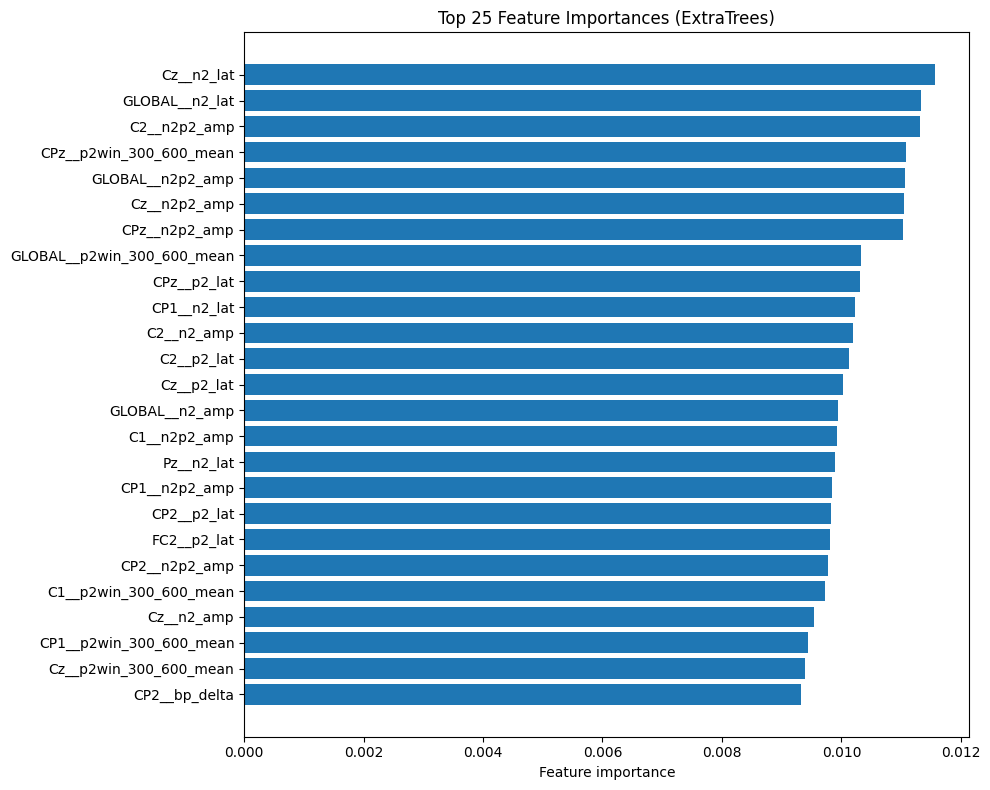

Saved figure: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/feature_importance/ExtraTrees_top25_feature_importance.png

Fitting: RandomForest
Saved: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/feature_importance/RandomForest_feature_importance_top120.csv


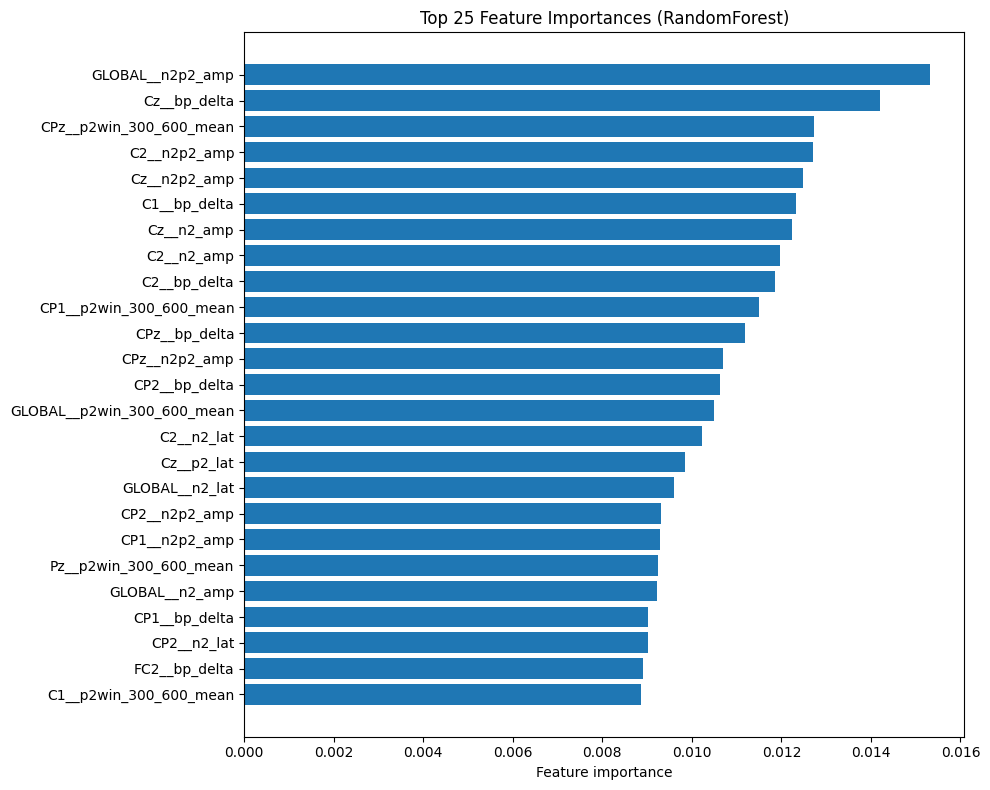

Saved figure: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/feature_importance/RandomForest_top25_feature_importance.png

Saved combined importance: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/feature_importance/combined_RF_ExtraTrees_mean_feature_importance.csv


,feature,mean_importance,std_importance,models_present,rank
0,GLOBAL__n2p2_amp,0.013189,0.003013,2,1
1,C2__n2p2_amp,0.012007,0.000979,2,2
2,CPz__p2win_300_600_mean,0.011901,0.001155,2,3
3,Cz__n2p2_amp,0.011766,0.001008,2,4
4,Cz__bp_delta,0.011699,0.003532,2,5
5,Cz__n2_lat,0.011566,NaN,1,6
6,C2__n2_amp,0.011077,0.001259,2,7
7,Cz__n2_amp,0.010893,0.001900,2,8
8,CPz__n2p2_amp,0.010866,0.000245,2,9
9,C1__bp_delta,0.010768,0.002208,2,10


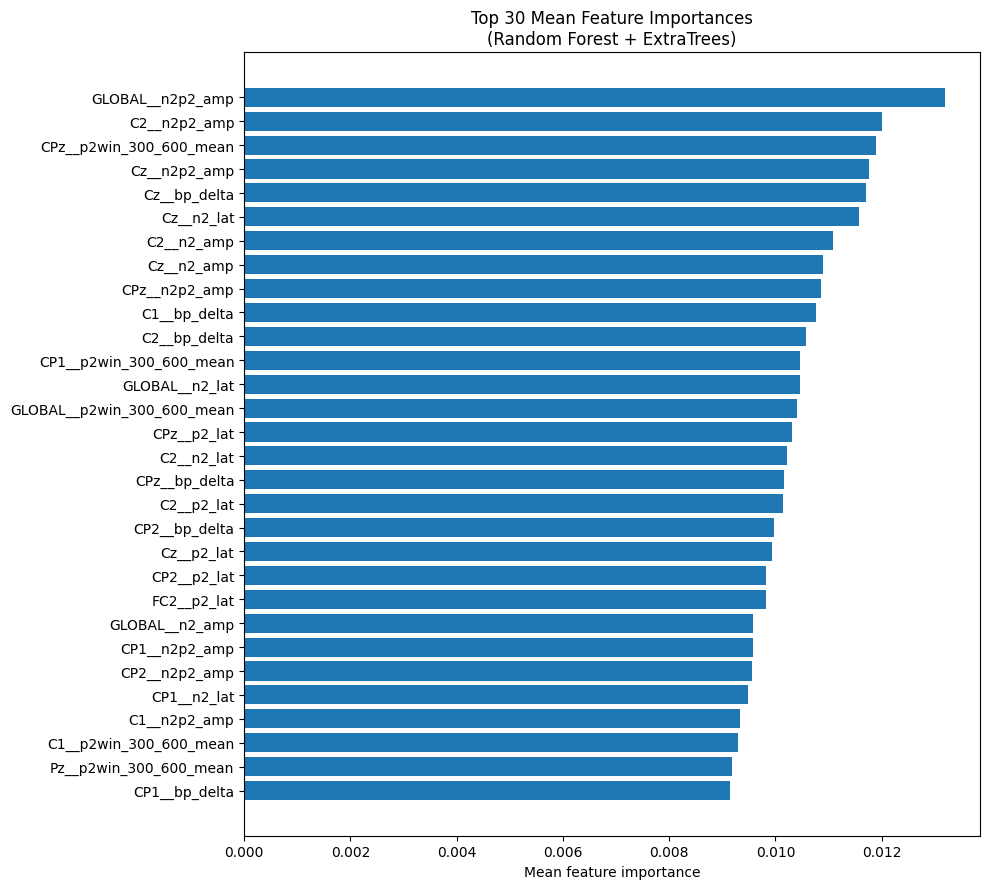

Saved figure: /content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/feature_importance/combined_RF_ExtraTrees_top30_feature_importance.png


In [ ]:
# CELL — Feature importance for proposed 230-feature pipeline
# ExtraTrees + RandomForest
# Uses full dataset only for interpretability/reporting after LOSO evaluation is complete.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

OUT_DIR = "/content/drive/MyDrive/EXP8_CLASSIFICATION_FROM_SCRATCH"
SAVE_DIR = "/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML"
FIG_DIR = os.path.join(SAVE_DIR, "feature_importance")
os.makedirs(FIG_DIR, exist_ok=True)

ML_READY_PATH = os.path.join(OUT_DIR, "exp8_classification_ml_ready.csv")
df = pd.read_csv(ML_READY_PATH)

non_feature_cols = [
    "experiment", "subject_id", "trial_num",
    "painrating", "pain_label", "pain_class",
    "laser_power", "event_type", "source_file"
]

feature_cols = [c for c in df.columns if c not in non_feature_cols]

X = df[feature_cols].values.astype(float)
y = df["pain_label"].values.astype(int)

print("X:", X.shape)
print("y:", y.shape)
print("Feature count:", len(feature_cols))

K_FEATURES = 120

models_for_importance = {
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

all_importance_tables = []

for model_name, clf in models_for_importance.items():
    print("\nFitting:", model_name)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(mutual_info_classif, k=min(K_FEATURES, X.shape[1]))),
        ("clf", clf)
    ])

    pipe.fit(X, y)

    selector = pipe.named_steps["selector"]
    selected_mask = selector.get_support()
    selected_features = np.array(feature_cols)[selected_mask]

    importances = pipe.named_steps["clf"].feature_importances_

    imp_df = pd.DataFrame({
        "model": model_name,
        "feature": selected_features,
        "importance": importances
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    imp_df["rank"] = np.arange(1, len(imp_df) + 1)

    save_path = os.path.join(FIG_DIR, f"{model_name}_feature_importance_top120.csv")
    imp_df.to_csv(save_path, index=False)
    print("Saved:", save_path)

    all_importance_tables.append(imp_df)

    # Top 25 plot
    top_n = 25
    plot_df = imp_df.head(top_n).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.xlabel("Feature importance")
    plt.title(f"Top {top_n} Feature Importances ({model_name})")
    plt.tight_layout()

    fig_path = os.path.join(FIG_DIR, f"{model_name}_top{top_n}_feature_importance.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", fig_path)

# Combined importance: average ExtraTrees + RandomForest
combined_df = pd.concat(all_importance_tables, ignore_index=True)

avg_imp = (
    combined_df
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std"),
        models_present=("model", "nunique")
    )
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

avg_imp["rank"] = np.arange(1, len(avg_imp) + 1)

combined_path = os.path.join(FIG_DIR, "combined_RF_ExtraTrees_mean_feature_importance.csv")
avg_imp.to_csv(combined_path, index=False)

print("\nSaved combined importance:", combined_path)
display(avg_imp.head(30))

# Combined top 30 plot
top_n = 30
plot_df = avg_imp.head(top_n).sort_values("mean_importance", ascending=True)

plt.figure(figsize=(10, 9))
plt.barh(plot_df["feature"], plot_df["mean_importance"])
plt.xlabel("Mean feature importance")
plt.title("Top 30 Mean Feature Importances\n(Random Forest + ExtraTrees)")
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "combined_RF_ExtraTrees_top30_feature_importance.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)

In [ ]:
# PARALLEL EXPERIMENT — Fixed soft-voting ensemble from saved LOSO predictions
# No model retraining is required.

import os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

SAVE_DIR = "/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML"

MODEL_NAMES = [
    "ExtraTrees",
    "RandomForest",
    "SVM_RBF",
    "LDA",
    "XGBoost",
    "LogisticRegression"
]

prediction_tables = {}

for model_name in MODEL_NAMES:
    path = os.path.join(SAVE_DIR, f"predictions_{model_name}.csv")

    if not os.path.exists(path):
        print("Missing:", path)
        continue

    df_pred = pd.read_csv(path)

    required = {"y_true", "y_pred", "y_score"}
    if not required.issubset(df_pred.columns):
        raise ValueError(
            f"{model_name} prediction file does not contain "
            f"the required columns: {required}"
        )

    prediction_tables[model_name] = df_pred.reset_index(drop=True)
    print(model_name, df_pred.shape)

if len(prediction_tables) < 2:
    raise ValueError("At least two prediction files are required.")

# Verify that all prediction files refer to the same samples
reference_name = list(prediction_tables.keys())[0]
reference_true = prediction_tables[reference_name]["y_true"].to_numpy(dtype=int)
n_samples = len(reference_true)

for model_name, table in prediction_tables.items():
    if len(table) != n_samples:
        raise ValueError(
            f"Sample-count mismatch for {model_name}: "
            f"{len(table)} versus {n_samples}"
        )

    current_true = table["y_true"].to_numpy(dtype=int)

    if not np.array_equal(reference_true, current_true):
        raise ValueError(
            f"y_true ordering mismatch in predictions_{model_name}.csv"
        )

# Equal-weight soft voting
score_matrix = np.column_stack([
    prediction_tables[name]["y_score"].to_numpy(dtype=float)
    for name in prediction_tables
])

ensemble_score = np.mean(score_matrix, axis=1)
ensemble_pred = (ensemble_score >= 0.50).astype(int)
y_true = reference_true

result = {
    "Model": "EqualWeight_SoftVoting_All6",
    "Members": " + ".join(prediction_tables.keys()),
    "Threshold": 0.50,
    "Accuracy": accuracy_score(y_true, ensemble_pred),
    "Balanced_Accuracy": balanced_accuracy_score(y_true, ensemble_pred),
    "Precision": precision_score(y_true, ensemble_pred, zero_division=0),
    "Recall": recall_score(y_true, ensemble_pred, zero_division=0),
    "F1": f1_score(y_true, ensemble_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_true, ensemble_score)
}

result_df = pd.DataFrame([result])

ensemble_predictions_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": ensemble_pred,
    "y_score": ensemble_score
})

cm = confusion_matrix(y_true, ensemble_pred)
cm_df = pd.DataFrame(
    cm,
    index=["True_Low", "True_High"],
    columns=["Pred_Low", "Pred_High"]
)

result_path = os.path.join(
    SAVE_DIR,
    "final_result_EqualWeight_SoftVoting_All6.csv"
)

prediction_path = os.path.join(
    SAVE_DIR,
    "predictions_EqualWeight_SoftVoting_All6.csv"
)

cm_path = os.path.join(
    SAVE_DIR,
    "confusion_EqualWeight_SoftVoting_All6.csv"
)

result_df.to_csv(result_path, index=False)
ensemble_predictions_df.to_csv(prediction_path, index=False)
cm_df.to_csv(cm_path)

display(result_df)
print("\nConfusion matrix:")
print(cm)

print("\nSaved:")
print(result_path)
print(prediction_path)
print(cm_path)

ExtraTrees (6275, 3)
RandomForest (6275, 3)
SVM_RBF (6275, 3)
LDA (6275, 3)
XGBoost (6275, 3)
LogisticRegression (6275, 3)


,Model,Members,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,EqualWeight_SoftVoting_All6,ExtraTrees + RandomForest + SVM_RBF + LDA + XG...,0.5,0.64,0.634499,0.683851,0.676338,0.680074,0.677892



Confusion matrix:
[[1615 1110]
 [1149 2401]]

Saved:
/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/final_result_EqualWeight_SoftVoting_All6.csv
/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/predictions_EqualWeight_SoftVoting_All6.csv
/content/drive/MyDrive/EXP8_PROPOSED_230_FEATURE_ML/confusion_EqualWeight_SoftVoting_All6.csv


In [ ]:
# Focused three-model ensemble:
# ExtraTrees + RandomForest + SVM-RBF

FOCUSED_MODELS = [
    "ExtraTrees",
    "RandomForest",
    "SVM_RBF"
]

score_matrix = np.column_stack([
    prediction_tables[name]["y_score"].to_numpy(dtype=float)
    for name in FOCUSED_MODELS
])

focused_score = np.mean(score_matrix, axis=1)
focused_pred = (focused_score >= 0.50).astype(int)

focused_result = pd.DataFrame([{
    "Model": "EqualWeight_SoftVoting_ET_RF_SVM",
    "Members": " + ".join(FOCUSED_MODELS),
    "Threshold": 0.50,
    "Accuracy": accuracy_score(y_true, focused_pred),
    "Balanced_Accuracy": balanced_accuracy_score(y_true, focused_pred),
    "Precision": precision_score(y_true, focused_pred, zero_division=0),
    "Recall": recall_score(y_true, focused_pred, zero_division=0),
    "F1": f1_score(y_true, focused_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_true, focused_score)
}])

focused_predictions = pd.DataFrame({
    "y_true": y_true,
    "y_pred": focused_pred,
    "y_score": focused_score
})

focused_cm = confusion_matrix(y_true, focused_pred)

focused_result.to_csv(
    os.path.join(SAVE_DIR, "final_result_EqualWeight_SoftVoting_ET_RF_SVM.csv"),
    index=False
)

focused_predictions.to_csv(
    os.path.join(SAVE_DIR, "predictions_EqualWeight_SoftVoting_ET_RF_SVM.csv"),
    index=False
)

pd.DataFrame(
    focused_cm,
    index=["True_Low", "True_High"],
    columns=["Pred_Low", "Pred_High"]
).to_csv(
    os.path.join(SAVE_DIR, "confusion_EqualWeight_SoftVoting_ET_RF_SVM.csv")
)

display(focused_result)
print(focused_cm)

,Model,Members,Threshold,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,EqualWeight_SoftVoting_ET_RF_SVM,ExtraTrees + RandomForest + SVM_RBF,0.5,0.639522,0.632201,0.679088,0.687887,0.683459,0.676115


[[1571 1154]
 [1108 2442]]


improved pipeline implementation starts=>


In [ ]:
# ============================================================
# PIPELINE V2 — BASELINE-NORMALIZED ENHANCED FEATURE EXTRACTION
#
# Purpose:
#   1. Reduce trial-to-trial and subject-to-subject amplitude-scale variation.
#   2. Preserve pain-related N2/P2 morphology.
#   3. Add relative/log spectral features that may generalize better.
#   4. Fuse the enhanced representation with the original 230 features.
#
# Required existing notebook variables/functions:
#   set_files
#   REREFER_DIR
#   read_mat
#   safe_scalar
#   get_subject_id
#   load_eeg_data_from_set
#   get_times_ms
#   get_channel_labels
#   clean_channel_name
#   extract_trial_metadata_from_epoch

# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm
from scipy.signal import welch
from scipy.stats import skew, kurtosis


# ============================================================
# 1. Input and output paths
# ============================================================

ORIGINAL_OUT_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH"
)

V2_OUT_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_PIPELINE_V2_BASELINE_NORMALIZED"
)

os.makedirs(
    V2_OUT_DIR,
    exist_ok=True
)

ORIGINAL_ML_PATH = os.path.join(
    ORIGINAL_OUT_DIR,
    "exp8_classification_ml_ready.csv"
)

V2_ENHANCED_PATH = os.path.join(
    V2_OUT_DIR,
    "exp8_v2_baseline_normalized_features.csv"
)

V2_FUSED_PATH = os.path.join(
    V2_OUT_DIR,
    "exp8_v2_fused_original230_plus_normalized.csv"
)

V2_FAILED_PATH = os.path.join(
    V2_OUT_DIR,
    "exp8_v2_feature_extraction_failed.csv"
)



In [ ]:
# ============================================================
# 2. Read original 230-feature dataframe
# ============================================================

original_df = pd.read_csv(
    ORIGINAL_ML_PATH
)

metadata_columns = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class",
    "laser_power",
    "event_type",
    "source_file"
]

original_feature_columns = [
    column
    for column in original_df.columns
    if column not in metadata_columns
]

print("Original dataframe:", original_df.shape)
print("Original feature count:", len(original_feature_columns))


Original dataframe: (6275, 239)
Original feature count: 230


In [ ]:
# ============================================================
# 3. Recover the exact channels used in the original pipeline
#
# Example:
#   Cz__n2_amp -> Cz
# ============================================================

original_channel_names = []

for feature_name in original_feature_columns:

    if "__" not in feature_name:
        continue

    prefix = feature_name.split(
        "__",
        1
    )[0]

    if prefix != "GLOBAL":
        original_channel_names.append(
            prefix
        )

CORE_CHANNELS_V2 = sorted(
    set(original_channel_names)
)

print("Channels recovered from original features:")
print(CORE_CHANNELS_V2)
print("Channel count:", len(CORE_CHANNELS_V2))

Channels recovered from original features:
['C1', 'C2', 'CP1', 'CP2', 'CPz', 'Cz', 'FC1', 'FC2', 'Fz', 'Pz']
Channel count: 10


In [ ]:
# ============================================================
# 4. Time windows and frequency bands
# ============================================================

TEMPORAL_WINDOWS = {
    "early_0_200": (0, 200),
    "n2win_180_350": (180, 350),
    "p2win_300_600": (300, 600),
    "late_600_1000": (600, 1000),
    "global_0_1000": (0, 1000)
}

FREQUENCY_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

BASELINE_START_MS = -1000
BASELINE_END_MS = 0

POST_START_MS = 0
POST_END_MS = 1000

EPSILON = 1e-8

In [ ]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

import numpy as np
from scipy.signal import welch
from scipy.stats import skew, kurtosis


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

TEMPORAL_WINDOWS = {
    "early_0_200": (0, 200),
    "n2win_180_350": (180, 350),
    "p2win_300_600": (300, 600),
    "late_600_1000": (600, 1000),
    "global_0_1000": (0, 1000)
}

FREQUENCY_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

BASELINE_START_MS = -1000
BASELINE_END_MS = 0

POST_START_MS = 0
POST_END_MS = 1000

EPSILON = 1e-8


# ------------------------------------------------------------
# Baseline z-normalization
# ------------------------------------------------------------

def trial_baseline_zscore(
    signal,
    times_ms,
    baseline_start=-1000,
    baseline_end=0,
    epsilon=1e-8
):
    signal = np.asarray(signal, dtype=float)
    times_ms = np.asarray(times_ms, dtype=float)

    baseline_idx = np.where(
        (times_ms >= baseline_start) &
        (times_ms < baseline_end)
    )[0]

    if len(baseline_idx) == 0:
        raise ValueError(
            "The requested baseline interval is absent from the epoch."
        )

    baseline_signal = signal[baseline_idx]

    baseline_mean = np.nanmean(baseline_signal)
    baseline_std = np.nanstd(baseline_signal)

    if not np.isfinite(baseline_mean):
        baseline_mean = 0.0

    if not np.isfinite(baseline_std) or baseline_std < epsilon:
        baseline_std = 1.0

    normalized_signal = (
        signal - baseline_mean
    ) / (
        baseline_std + epsilon
    )

    return (
        normalized_signal,
        float(baseline_mean),
        float(baseline_std)
    )


# ------------------------------------------------------------
# Extract samples from one temporal window
# ------------------------------------------------------------

def get_window_indices(
    times_ms,
    start_ms,
    end_ms
):
    times_ms = np.asarray(times_ms, dtype=float)

    return np.where(
        (times_ms >= start_ms) &
        (times_ms <= end_ms)
    )[0]


def window_mean(
    signal,
    times_ms,
    start_ms,
    end_ms
):
    signal = np.asarray(signal, dtype=float)

    idx = get_window_indices(
        times_ms,
        start_ms,
        end_ms
    )

    if len(idx) == 0:
        return np.nan

    values = signal[idx]

    if np.all(~np.isfinite(values)):
        return np.nan

    return float(np.nanmean(values))


# ------------------------------------------------------------
# Area under the EEG waveform within one interval
# ------------------------------------------------------------

def window_auc(
    signal,
    times_ms,
    start_ms,
    end_ms
):
    signal = np.asarray(signal, dtype=float)
    times_ms = np.asarray(times_ms, dtype=float)

    idx = get_window_indices(
        times_ms,
        start_ms,
        end_ms
    )

    if len(idx) < 2:
        return np.nan

    values = signal[idx]
    local_times = times_ms[idx] / 1000.0

    finite_mask = (
        np.isfinite(values) &
        np.isfinite(local_times)
    )

    if finite_mask.sum() < 2:
        return np.nan

    return float(
        np.trapezoid(
            values[finite_mask],
            local_times[finite_mask]
        )
    )


# ------------------------------------------------------------
# Linear slope within one interval
# ------------------------------------------------------------

def window_slope(
    signal,
    times_ms,
    start_ms,
    end_ms
):
    signal = np.asarray(signal, dtype=float)
    times_ms = np.asarray(times_ms, dtype=float)

    idx = get_window_indices(
        times_ms,
        start_ms,
        end_ms
    )

    if len(idx) < 2:
        return np.nan

    values = signal[idx]
    local_times = times_ms[idx] / 1000.0

    finite_mask = (
        np.isfinite(values) &
        np.isfinite(local_times)
    )

    if finite_mask.sum() < 2:
        return np.nan

    slope = np.polyfit(
        local_times[finite_mask],
        values[finite_mask],
        deg=1
    )[0]

    return float(slope)


# ------------------------------------------------------------
# Peak amplitude and latency
# ------------------------------------------------------------

def peak_amplitude_latency(
    signal,
    times_ms,
    start_ms,
    end_ms,
    mode="minimum"
):
    signal = np.asarray(signal, dtype=float)
    times_ms = np.asarray(times_ms, dtype=float)

    idx = get_window_indices(
        times_ms,
        start_ms,
        end_ms
    )

    if len(idx) == 0:
        return np.nan, np.nan

    values = signal[idx]

    if np.all(~np.isfinite(values)):
        return np.nan, np.nan

    if mode == "minimum":
        local_idx = np.nanargmin(values)

    elif mode == "maximum":
        local_idx = np.nanargmax(values)

    else:
        raise ValueError(
            "mode must be either 'minimum' or 'maximum'."
        )

    amplitude = values[local_idx]
    latency = times_ms[idx[local_idx]]

    return float(amplitude), float(latency)


# ------------------------------------------------------------
# Absolute, logarithmic and relative bandpower
# ------------------------------------------------------------

def compute_bandpower_dictionary(
    signal,
    sampling_rate,
    bands
):
    signal = np.asarray(signal, dtype=float)

    output = {
        band_name: {
            "absolute": np.nan,
            "log": np.nan,
            "relative": np.nan
        }
        for band_name in bands
    }

    finite_values = signal[np.isfinite(signal)]

    if len(finite_values) < 4:
        return output

    fill_value = np.nanmedian(signal)

    if not np.isfinite(fill_value):
        fill_value = 0.0

    clean_signal = np.nan_to_num(
        signal,
        nan=fill_value,
        posinf=fill_value,
        neginf=fill_value
    )

    frequencies, psd = welch(
        clean_signal,
        fs=sampling_rate,
        nperseg=min(512, len(clean_signal))
    )

    total_idx = np.where(
        (frequencies >= 1) &
        (frequencies <= 45)
    )[0]

    if len(total_idx) >= 2:
        total_power = np.trapezoid(
            psd[total_idx],
            frequencies[total_idx]
        )
    else:
        total_power = np.nan

    for band_name, (
        minimum_frequency,
        maximum_frequency
    ) in bands.items():

        band_idx = np.where(
            (frequencies >= minimum_frequency) &
            (frequencies <= maximum_frequency)
        )[0]

        if len(band_idx) >= 2:
            absolute_power = np.trapezoid(
                psd[band_idx],
                frequencies[band_idx]
            )
        else:
            absolute_power = np.nan

        if np.isfinite(absolute_power):
            log_power = np.log10(
                absolute_power + EPSILON
            )
        else:
            log_power = np.nan

        if (
            np.isfinite(absolute_power) and
            np.isfinite(total_power) and
            total_power > 0
        ):
            relative_power = (
                absolute_power / total_power
            )
        else:
            relative_power = np.nan

        output[band_name] = {
            "absolute": float(absolute_power)
            if np.isfinite(absolute_power)
            else np.nan,

            "log": float(log_power)
            if np.isfinite(log_power)
            else np.nan,

            "relative": float(relative_power)
            if np.isfinite(relative_power)
            else np.nan
        }

    return output


# ------------------------------------------------------------
# Statistical descriptors
# ------------------------------------------------------------

def normalized_signal_statistics(
    signal
):
    signal = np.asarray(signal, dtype=float)

    finite_signal = signal[np.isfinite(signal)]

    if len(finite_signal) == 0:
        return {
            "std": np.nan,
            "rms": np.nan,
            "skew": np.nan,
            "kurtosis": np.nan,
            "peak_to_peak": np.nan
        }

    if len(finite_signal) > 2:
        skewness = skew(
            finite_signal,
            bias=False
        )
    else:
        skewness = np.nan

    if len(finite_signal) > 3:
        kurtosis_value = kurtosis(
            finite_signal,
            bias=False
        )
    else:
        kurtosis_value = np.nan

    return {
        "std": float(np.std(finite_signal)),

        "rms": float(
            np.sqrt(
                np.mean(finite_signal ** 2)
            )
        ),

        "skew": float(skewness)
        if np.isfinite(skewness)
        else np.nan,

        "kurtosis": float(kurtosis_value)
        if np.isfinite(kurtosis_value)
        else np.nan,

        "peak_to_peak": float(
            np.ptp(finite_signal)
        )
    }


# ------------------------------------------------------------
# MAIN FUNCTION
#
# Important:
# Everything below remains indented inside the function.
# Do not run its body separately.
# ------------------------------------------------------------

def add_v2_features_for_signal(
    row,
    signal,
    times_ms,
    sampling_rate,
    feature_prefix
):
    """
    Adds baseline-normalized temporal, morphological,
    spectral and statistical EEG features to `row`.

    Parameters
    ----------
    row : dict
        Dictionary representing one EEG trial.

    signal : array-like
        One normalized EEG channel or global averaged signal.

    times_ms : array-like
        Epoch times in milliseconds.

    sampling_rate : float
        EEG sampling frequency in Hz.

    feature_prefix : str
        Channel label, for example Cz, CPz or GLOBAL.
    """

    signal = np.asarray(
        signal,
        dtype=float
    )

    times_ms = np.asarray(
        times_ms,
        dtype=float
    )

    if len(signal) != len(times_ms):
        raise ValueError(
            f"Signal/time length mismatch for {feature_prefix}: "
            f"{len(signal)} versus {len(times_ms)}."
        )

    # ========================================================
    # A. Temporal window means
    # ========================================================

    for window_name, (
        start_ms,
        end_ms
    ) in TEMPORAL_WINDOWS.items():

        row[
            f"{feature_prefix}__zmean_{window_name}"
        ] = window_mean(
            signal=signal,
            times_ms=times_ms,
            start_ms=start_ms,
            end_ms=end_ms
        )

    # ========================================================
    # B. N2 and P2 morphology
    # ========================================================

    n2_amplitude, n2_latency = (
        peak_amplitude_latency(
            signal=signal,
            times_ms=times_ms,
            start_ms=180,
            end_ms=350,
            mode="minimum"
        )
    )

    p2_amplitude, p2_latency = (
        peak_amplitude_latency(
            signal=signal,
            times_ms=times_ms,
            start_ms=300,
            end_ms=600,
            mode="maximum"
        )
    )

    row[
        f"{feature_prefix}__z_n2_amp"
    ] = n2_amplitude

    row[
        f"{feature_prefix}__z_n2_lat"
    ] = n2_latency

    row[
        f"{feature_prefix}__z_p2_amp"
    ] = p2_amplitude

    row[
        f"{feature_prefix}__z_p2_lat"
    ] = p2_latency

    if (
        np.isfinite(n2_amplitude) and
        np.isfinite(p2_amplitude)
    ):
        row[
            f"{feature_prefix}__z_n2p2_amp"
        ] = (
            p2_amplitude - n2_amplitude
        )
    else:
        row[
            f"{feature_prefix}__z_n2p2_amp"
        ] = np.nan

    # ========================================================
    # C. N2/P2 area under the curve
    # ========================================================

    row[
        f"{feature_prefix}__z_n2_auc"
    ] = window_auc(
        signal=signal,
        times_ms=times_ms,
        start_ms=180,
        end_ms=350
    )

    row[
        f"{feature_prefix}__z_p2_auc"
    ] = window_auc(
        signal=signal,
        times_ms=times_ms,
        start_ms=300,
        end_ms=600
    )

    # ========================================================
    # D. N2/P2 slopes
    # ========================================================

    row[
        f"{feature_prefix}__z_n2_slope"
    ] = window_slope(
        signal=signal,
        times_ms=times_ms,
        start_ms=180,
        end_ms=350
    )

    row[
        f"{feature_prefix}__z_p2_slope"
    ] = window_slope(
        signal=signal,
        times_ms=times_ms,
        start_ms=300,
        end_ms=600
    )

    # ========================================================
    # E. Select post-stimulus interval
    # ========================================================

    post_idx = get_window_indices(
        times_ms=times_ms,
        start_ms=POST_START_MS,
        end_ms=POST_END_MS
    )

    if len(post_idx) == 0:
        post_signal = np.array(
            [],
            dtype=float
        )
    else:
        post_signal = signal[
            post_idx
        ]

    # ========================================================
    # F. Log and relative spectral power
    # ========================================================

    bandpower_results = (
        compute_bandpower_dictionary(
            signal=post_signal,
            sampling_rate=sampling_rate,
            bands=FREQUENCY_BANDS
        )
    )

    for band_name, band_values in (
        bandpower_results.items()
    ):
        row[
            f"{feature_prefix}__z_logbp_{band_name}"
        ] = band_values["log"]

        row[
            f"{feature_prefix}__z_relbp_{band_name}"
        ] = band_values["relative"]

    # ========================================================
    # G. Statistical descriptors
    # ========================================================

    statistics = normalized_signal_statistics(
        post_signal
    )

    for (
        statistic_name,
        statistic_value
    ) in statistics.items():

        row[
            f"{feature_prefix}__z_{statistic_name}"
        ] = statistic_value

    return row


print("Corrected Pipeline V2 helper functions loaded successfully.")
print("Available main function: add_v2_features_for_signal(...)")

Corrected Pipeline V2 helper functions loaded successfully.
Available main function: add_v2_features_for_signal(...)


In [ ]:
# ============================================================
# 6. Extract Pipeline V2 features
# ============================================================

v2_rows = []
failed_rows = []

for set_path in tqdm(
    set_files,
    desc="Extracting Pipeline V2 features"
):
    subject_id = get_subject_id(
        set_path
    )

    try:
        mat = read_mat(
            set_path
        )

        data = load_eeg_data_from_set(
            mat,
            set_path,
            REREFER_DIR
        )

        times_ms = get_times_ms(
            mat
        )

        number_of_channels = int(
            safe_scalar(
                mat["nbchan"]
            )
        )

        number_of_trials = int(
            safe_scalar(
                mat["trials"]
            )
        )

        sampling_rate = float(
            safe_scalar(
                mat.get(
                    "srate",
                    1000
                )
            )
        )

        channel_labels = get_channel_labels(
            mat.get(
                "chanlocs",
                []
            ),
            nbchan=number_of_channels
        )

        channel_to_index = {
            clean_channel_name(channel):
            channel_index

            for channel_index, channel
            in enumerate(channel_labels)
        }

        available_channels = [
            channel

            for channel in CORE_CHANNELS_V2

            if clean_channel_name(channel)
            in channel_to_index
        ]

        if len(available_channels) == 0:
            raise ValueError(
                "No required V2 channels were found."
            )

        pain_ratings, laser_powers, event_types = (
            extract_trial_metadata_from_epoch(
                mat,
                number_of_trials
            )
        )

        for trial_index in range(
            number_of_trials
        ):
            row = {
                "experiment": "EXP8",
                "subject_id": subject_id,
                "trial_num": trial_index + 1,
                "painrating": safe_scalar(
                    pain_ratings[trial_index]
                ),
                "laser_power": safe_scalar(
                    laser_powers[trial_index]
                ),
                "event_type": safe_scalar(
                    event_types[trial_index]
                ),
                "source_file": os.path.basename(
                    set_path
                )
            }

            normalized_channel_signals = []

            for channel_name in available_channels:
                clean_name = clean_channel_name(
                    channel_name
                )

                channel_index = channel_to_index[
                    clean_name
                ]

                original_signal = data[
                    channel_index,
                    :,
                    trial_index
                ].astype(float)

                (
                    normalized_signal,
                    baseline_mean,
                    baseline_std
                ) = trial_baseline_zscore(
                    signal=original_signal,
                    times_ms=times_ms,
                    baseline_start=BASELINE_START_MS,
                    baseline_end=BASELINE_END_MS,
                    epsilon=EPSILON
                )

                normalized_channel_signals.append(
                    normalized_signal
                )

                # Store baseline descriptors
                row[
                    f"{clean_name}__baseline_mean"
                ] = baseline_mean

                row[
                    f"{clean_name}__baseline_std"
                ] = baseline_std

                # Add normalized temporal/spectral features
                add_v2_features_for_signal(
                    row=row,
                    signal=normalized_signal,
                    times_ms=times_ms,
                    sampling_rate=sampling_rate,
                    feature_prefix=clean_name
                )

            # ------------------------------------------------
            # Global signal across selected channels
            # ------------------------------------------------

            if len(
                normalized_channel_signals
            ) > 0:

                global_normalized_signal = (
                    np.nanmean(
                        np.vstack(
                            normalized_channel_signals
                        ),
                        axis=0
                    )
                )

                add_v2_features_for_signal(
                    row=row,
                    signal=global_normalized_signal,
                    times_ms=times_ms,
                    sampling_rate=sampling_rate,
                    feature_prefix="GLOBAL"
                )

            v2_rows.append(
                row
            )

    except Exception as error:
        failed_rows.append({
            "subject_id": subject_id,
            "source_file": os.path.basename(
                set_path
            ),
            "error": str(error)
        })



Extracting Pipeline V2 features: 100%|██████████| 223/223 [10:08<00:00,  2.73s/it]


In [ ]:
# ============================================================
# FINAL V2 SAVE + FUSION CELL
# This cell:
# 1. Uses the already-created v2_rows
# 2. Saves the enhanced V2 features
# 3. Loads the original 230-feature dataset
# 4. Fuses original + V2 features
# 5. Saves the final fused dataset
# ============================================================

import os
import numpy as np
import pandas as pd

# ============================================================
# 1. Define all required paths
# ============================================================

V2_OUT_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_PIPELINE_V2_BASELINE_NORMALIZED"
)

ORIGINAL_ML_PATH = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "exp8_classification_ml_ready.csv"
)

V2_ENHANCED_PATH = os.path.join(
    V2_OUT_DIR,
    "exp8_v2_baseline_normalized_features.csv"
)

V2_FAILED_PATH = os.path.join(
    V2_OUT_DIR,
    "exp8_v2_feature_extraction_failed.csv"
)

V2_FUSED_PATH = os.path.join(
    V2_OUT_DIR,
    "exp8_v2_fused_original230_plus_normalized.csv"
)

os.makedirs(
    V2_OUT_DIR,
    exist_ok=True
)

# ============================================================
# 2. Check that extraction results still exist
# ============================================================

if "v2_rows" not in globals():
    raise RuntimeError(
        "v2_rows is not available in memory. "
        "The runtime may have restarted. "
        "Rerun only the V2 extraction cell, then run this cell again."
    )

if "failed_rows" not in globals():
    failed_rows = []

print("V2 rows found in memory:", len(v2_rows))
print("Failed file records:", len(failed_rows))

if len(v2_rows) == 0:
    raise RuntimeError(
        "v2_rows is empty. No V2 trials were extracted."
    )

# ============================================================
# 3. Convert extracted rows into DataFrames
# ============================================================

v2_enhanced_df = pd.DataFrame(
    v2_rows
)

failed_v2_df = pd.DataFrame(
    failed_rows
)

required_columns = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating"
]

missing_columns = [
    column
    for column in required_columns
    if column not in v2_enhanced_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns in V2 data: {missing_columns}"
    )

# ============================================================
# 4. Recreate pain labels
# ============================================================

v2_enhanced_df["painrating"] = pd.to_numeric(
    v2_enhanced_df["painrating"],
    errors="coerce"
)

missing_ratings = int(
    v2_enhanced_df["painrating"].isna().sum()
)

if missing_ratings > 0:
    raise ValueError(
        f"{missing_ratings} V2 trials have missing pain ratings."
    )

v2_enhanced_df["pain_label"] = np.where(
    v2_enhanced_df["painrating"] >= 5,
    1,
    0
)

v2_enhanced_df["pain_class"] = np.where(
    v2_enhanced_df["pain_label"] == 1,
    "high_pain",
    "low_pain"
)

v2_enhanced_df = v2_enhanced_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# ============================================================
# 5. Check duplicate trial identifiers
# ============================================================

merge_keys = [
    "experiment",
    "subject_id",
    "trial_num"
]

duplicate_v2_rows = int(
    v2_enhanced_df.duplicated(
        subset=merge_keys
    ).sum()
)

if duplicate_v2_rows > 0:
    raise ValueError(
        f"Found {duplicate_v2_rows} duplicated V2 trial rows."
    )

# ============================================================
# 6. Save enhanced-only V2 dataset
# ============================================================

v2_enhanced_df.to_csv(
    V2_ENHANCED_PATH,
    index=False
)

failed_v2_df.to_csv(
    V2_FAILED_PATH,
    index=False
)

print("\nEnhanced V2 features saved successfully.")
print("Enhanced shape:", v2_enhanced_df.shape)
print(
    "Enhanced subjects:",
    v2_enhanced_df["subject_id"].nunique()
)
print("Enhanced trials:", len(v2_enhanced_df))
print("Saved:", V2_ENHANCED_PATH)

# ============================================================
# 7. Load original 230-feature dataset
# ============================================================

if not os.path.exists(ORIGINAL_ML_PATH):
    raise FileNotFoundError(
        f"Original ML-ready file not found:\n{ORIGINAL_ML_PATH}"
    )

original_df = pd.read_csv(
    ORIGINAL_ML_PATH
)

metadata_columns = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class",
    "laser_power",
    "event_type",
    "source_file"
]

original_feature_columns = [
    column
    for column in original_df.columns
    if column not in metadata_columns
]

print("\nOriginal dataframe shape:", original_df.shape)
print("Original feature count:", len(original_feature_columns))

# ============================================================
# 8. Identify only new V2 feature columns
# ============================================================

v2_feature_columns = [
    column
    for column in v2_enhanced_df.columns
    if column not in metadata_columns
]

print("New V2 feature count:", len(v2_feature_columns))

v2_merge_df = v2_enhanced_df[
    merge_keys + v2_feature_columns
].copy()

# ============================================================
# 9. Fuse original and V2 features
# ============================================================

fused_df = original_df.merge(
    v2_merge_df,
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

fused_df = fused_df.replace(
    [np.inf, -np.inf],
    np.nan
)

fused_feature_columns = [
    column
    for column in fused_df.columns
    if column not in metadata_columns
]

# ============================================================
# 10. Integrity checks
# ============================================================

print("\nIntegrity check")
print("Original trials:", len(original_df))
print("V2 trials:", len(v2_enhanced_df))
print("Merged trials:", len(fused_df))

if len(fused_df) != len(original_df):
    raise ValueError(
        "Merged row count does not match the original dataset. "
        f"Original={len(original_df)}, merged={len(fused_df)}"
    )

duplicate_fused_rows = int(
    fused_df.duplicated(
        subset=merge_keys
    ).sum()
)

if duplicate_fused_rows > 0:
    raise ValueError(
        f"Found {duplicate_fused_rows} duplicated fused rows."
    )

# ============================================================
# 11. Save final fused V2 dataset
# ============================================================

fused_df.to_csv(
    V2_FUSED_PATH,
    index=False
)

print("\n" + "=" * 72)
print("PIPELINE V2 SAVED SUCCESSFULLY")
print("=" * 72)

print("Original feature count:", len(original_feature_columns))
print("New V2 feature count:", len(v2_feature_columns))
print("Total fused feature count:", len(fused_feature_columns))

print("Final fused shape:", fused_df.shape)
print(
    "Final subjects:",
    fused_df["subject_id"].nunique()
)
print("Final trials:", len(fused_df))

print(
    "Remaining missing feature values:",
    int(
        fused_df[
            fused_feature_columns
        ].isna().sum().sum()
    )
)

print("\nEnhanced-only file:")
print(V2_ENHANCED_PATH)

print("\nFused feature file:")
print(V2_FUSED_PATH)

print("\nFailure log:")
print(V2_FAILED_PATH)

display(
    fused_df.head()
)

V2 rows found in memory: 6275
Failed file records: 0

Enhanced V2 features saved successfully.
Enhanced shape: (6275, 348)
Enhanced subjects: 223
Enhanced trials: 6275
Saved: /content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/exp8_v2_baseline_normalized_features.csv

Original dataframe shape: (6275, 239)
Original feature count: 230
New V2 feature count: 339

Integrity check
Original trials: 6275
V2 trials: 6275
Merged trials: 6275

PIPELINE V2 SAVED SUCCESSFULLY
Original feature count: 230
New V2 feature count: 339
Total fused feature count: 569
Final fused shape: (6275, 578)
Final subjects: 223
Final trials: 6275
Remaining missing feature values: 0

Enhanced-only file:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/exp8_v2_baseline_normalized_features.csv

Fused feature file:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/exp8_v2_fused_original230_plus_normalized.csv

Failure log:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/exp8_v2_fe

,experiment,subject_id,trial_num,painrating,laser_power,event_type,source_file,Cz__early_0_200_mean,Cz__n2win_180_350_mean,Cz__p2win_300_600_mean,...,GLOBAL__z_relbp_alpha,GLOBAL__z_logbp_beta,GLOBAL__z_relbp_beta,GLOBAL__z_logbp_gamma,GLOBAL__z_relbp_gamma,GLOBAL__z_std,GLOBAL__z_rms,GLOBAL__z_skew,GLOBAL__z_kurtosis,GLOBAL__z_peak_to_peak
0,EXP8,sub-001,1,0,3.5,S 32,sub-001_223ByBP.set,-1.533722,4.216710,2.784667,...,0.050265,-1.197485,0.129879,-2.643625,0.004649,0.843949,0.874186,0.415772,-0.815921,3.343914
1,EXP8,sub-001,2,5,4.0,S 33,sub-001_223ByBP.set,-4.118300,3.570035,1.912449,...,0.014759,-0.926649,0.039907,-2.635814,0.000780,1.451971,1.471274,0.350414,0.347373,7.653485
2,EXP8,sub-001,3,5,4.0,S 33,sub-001_223ByBP.set,-3.399629,3.723041,5.939103,...,0.019583,-1.016019,0.014399,-2.260904,0.000819,2.264316,2.334372,0.116281,0.954756,12.426973
3,EXP8,sub-001,4,3,3.5,S 32,sub-001_223ByBP.set,-0.333933,9.546207,4.363633,...,0.009347,-1.541168,0.030061,-3.300943,0.000523,0.902071,1.057094,0.930414,1.338115,4.547014
4,EXP8,sub-001,5,4,3.5,S 32,sub-001_223ByBP.set,-2.751706,-0.808219,1.233381,...,0.110231,-1.166830,0.124215,-2.720344,0.003473,0.921094,0.921264,0.246556,-0.855261,3.534704


In [ ]:
# ============================================================
# PIPELINE V2 — STRICT LOSO EXTRATREES COMPARISON
#
# Compares:
#   1. Original 230 handcrafted features
#   2. New 339 baseline-normalized V2 features
#   3. Fused 569 features
#
# Strict LOSO:
#   - One subject is held out completely
#   - Imputer and scaler are fitted only on training subjects
#   - No supervised feature selection is used initially
#   - Same ExtraTrees configuration for all representations
# ============================================================

import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. Paths
# ============================================================

ORIGINAL_PATH = (
    "/content/drive/MyDrive/"
    "EXP8_CLASSIFICATION_FROM_SCRATCH/"
    "exp8_classification_ml_ready.csv"
)

V2_NORMALIZED_PATH = (
    "/content/drive/MyDrive/"
    "EXP8_PIPELINE_V2_BASELINE_NORMALIZED/"
    "exp8_v2_baseline_normalized_features.csv"
)

V2_FUSED_PATH = (
    "/content/drive/MyDrive/"
    "EXP8_PIPELINE_V2_BASELINE_NORMALIZED/"
    "exp8_v2_fused_original230_plus_normalized.csv"
)

V2_RESULT_DIR = (
    "/content/drive/MyDrive/"
    "EXP8_PIPELINE_V2_BASELINE_NORMALIZED/"
    "STRICT_LOSO_RESULTS"
)

os.makedirs(
    V2_RESULT_DIR,
    exist_ok=True
)


# ============================================================
# 2. Metadata columns
# ============================================================

METADATA_COLUMNS = [
    "experiment",
    "subject_id",
    "trial_num",
    "painrating",
    "pain_label",
    "pain_class",
    "laser_power",
    "event_type",
    "source_file"
]


# ============================================================
# 3. Dataset loader
# ============================================================

def load_feature_dataset(
    csv_path
):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Dataset not found:\n{csv_path}"
        )

    dataframe = pd.read_csv(
        csv_path
    )

    required_columns = [
        "subject_id",
        "pain_label"
    ]

    missing_required = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_required:
        raise ValueError(
            f"Missing required columns: {missing_required}"
        )

    feature_columns = [
        column
        for column in dataframe.columns
        if column not in METADATA_COLUMNS
    ]

    # Ensure all features are numeric
    for column in feature_columns:
        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="coerce"
        )

    dataframe = dataframe.replace(
        [np.inf, -np.inf],
        np.nan
    )

    X = dataframe[
        feature_columns
    ].to_numpy(dtype=float)

    y = dataframe[
        "pain_label"
    ].to_numpy(dtype=int)

    groups = dataframe[
        "subject_id"
    ].to_numpy()

    return (
        dataframe,
        X,
        y,
        groups,
        feature_columns
    )


# ============================================================
# 4. Strict LOSO evaluator
# ============================================================

def evaluate_strict_loso_extratrees(
    dataset_name,
    csv_path,
    save_dir,
    random_state=42
):
    (
        dataframe,
        X,
        y,
        groups,
        feature_columns
    ) = load_feature_dataset(
        csv_path
    )

    print("\n" + "=" * 75)
    print("Dataset:", dataset_name)
    print("=" * 75)

    print("Dataframe shape:", dataframe.shape)
    print("X:", X.shape)
    print("y:", y.shape)
    print("Groups:", groups.shape)
    print("Subjects:", len(np.unique(groups)))
    print(
        "Class counts [low, high]:",
        np.bincount(y)
    )
    print("Feature count:", len(feature_columns))
    print(
        "Missing feature values:",
        int(np.isnan(X).sum())
    )

    result_path = os.path.join(
        save_dir,
        f"final_result_{dataset_name}.csv"
    )

    prediction_path = os.path.join(
        save_dir,
        f"predictions_{dataset_name}.csv"
    )

    fold_path = os.path.join(
        save_dir,
        f"fold_results_{dataset_name}.csv"
    )

    confusion_path = os.path.join(
        save_dir,
        f"confusion_{dataset_name}.csv"
    )

    logo = LeaveOneGroupOut()

    y_true_all = []
    y_pred_all = []
    y_score_all = []
    subject_all = []
    trial_all = []

    fold_rows = []

    splits = list(
        logo.split(
            X,
            y,
            groups
        )
    )

    total_start = time.perf_counter()

    for fold_number, (
        train_index,
        test_index
    ) in enumerate(
        tqdm(
            splits,
            total=len(splits),
            desc=dataset_name
        ),
        start=1
    ):
        X_train = X[
            train_index
        ]

        X_test = X[
            test_index
        ]

        y_train = y[
            train_index
        ]

        y_test = y[
            test_index
        ]

        test_subject = groups[
            test_index
        ][0]

        model = ExtraTreesClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        )

        pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "classifier",
                model
            )
        ])

        train_start = time.perf_counter()

        pipeline.fit(
            X_train,
            y_train
        )

        train_time = (
            time.perf_counter()
            - train_start
        )

        inference_start = time.perf_counter()

        y_pred = pipeline.predict(
            X_test
        )

        y_score = pipeline.predict_proba(
            X_test
        )[:, 1]

        inference_time_ms = (
            (
                time.perf_counter()
                - inference_start
            )
            / len(test_index)
            * 1000
        )

        y_true_all.extend(
            y_test.tolist()
        )

        y_pred_all.extend(
            y_pred.tolist()
        )

        y_score_all.extend(
            y_score.tolist()
        )

        subject_all.extend(
            [test_subject] * len(test_index)
        )

        if "trial_num" in dataframe.columns:
            trial_numbers = dataframe.iloc[
                test_index
            ]["trial_num"].tolist()
        else:
            trial_numbers = test_index.tolist()

        trial_all.extend(
            trial_numbers
        )

        try:
            fold_auc = roc_auc_score(
                y_test,
                y_score
            )
        except ValueError:
            fold_auc = np.nan

        fold_rows.append({
            "fold": fold_number,
            "test_subject": test_subject,
            "n_test_trials": len(test_index),
            "accuracy": accuracy_score(
                y_test,
                y_pred
            ),
            "balanced_accuracy":
                balanced_accuracy_score(
                    y_test,
                    y_pred
                ),
            "precision": precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),
            "roc_auc": fold_auc,
            "train_time_sec": train_time,
            "inference_ms_per_epoch":
                inference_time_ms
        })

        # Checkpoint after every subject
        pd.DataFrame(
            fold_rows
        ).to_csv(
            fold_path,
            index=False
        )

        pd.DataFrame({
            "subject_id": subject_all,
            "trial_num": trial_all,
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "y_score": y_score_all
        }).to_csv(
            prediction_path,
            index=False
        )

    # ========================================================
    # Final metrics
    # ========================================================

    y_true_all = np.asarray(
        y_true_all,
        dtype=int
    )

    y_pred_all = np.asarray(
        y_pred_all,
        dtype=int
    )

    y_score_all = np.asarray(
        y_score_all,
        dtype=float
    )

    fold_df = pd.DataFrame(
        fold_rows
    )

    total_runtime = (
        time.perf_counter()
        - total_start
    )

    final_result = {
        "Dataset": dataset_name,
        "Validation": (
            "Strict LOSO cross-individual"
        ),
        "Model": "ExtraTrees",
        "Subjects": len(np.unique(groups)),
        "Trials": len(y),
        "Feature_Count": len(feature_columns),
        "Accuracy": accuracy_score(
            y_true_all,
            y_pred_all
        ),
        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true_all,
                y_pred_all
            ),
        "Precision": precision_score(
            y_true_all,
            y_pred_all,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true_all,
            y_pred_all,
            zero_division=0
        ),
        "F1": f1_score(
            y_true_all,
            y_pred_all,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_true_all,
            y_score_all
        ),
        "Mean_Fold_Accuracy":
            fold_df[
                "accuracy"
            ].mean(),
        "Std_Fold_Accuracy":
            fold_df[
                "accuracy"
            ].std(),
        "Mean_Fold_Balanced_Accuracy":
            fold_df[
                "balanced_accuracy"
            ].mean(),
        "Mean_Fold_F1":
            fold_df[
                "f1"
            ].mean(),
        "Mean_Fold_ROC_AUC":
            fold_df[
                "roc_auc"
            ].mean(),
        "Mean_Inference_ms_per_epoch":
            fold_df[
                "inference_ms_per_epoch"
            ].mean(),
        "Total_Runtime_Minutes":
            total_runtime / 60
    }

    result_df = pd.DataFrame([
        final_result
    ])

    confusion = confusion_matrix(
        y_true_all,
        y_pred_all
    )

    confusion_df = pd.DataFrame(
        confusion,
        index=[
            "True_Low",
            "True_High"
        ],
        columns=[
            "Pred_Low",
            "Pred_High"
        ]
    )

    result_df.to_csv(
        result_path,
        index=False
    )

    confusion_df.to_csv(
        confusion_path
    )

    prediction_df = pd.DataFrame({
        "subject_id": subject_all,
        "trial_num": trial_all,
        "y_true": y_true_all,
        "y_pred": y_pred_all,
        "y_score": y_score_all
    })

    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    fold_df.to_csv(
        fold_path,
        index=False
    )

    display(result_df)

    print("\nConfusion matrix:")
    print(confusion)

    print("\nSaved:")
    print(result_path)
    print(prediction_path)
    print(fold_path)
    print(confusion_path)

    return (
        result_df,
        fold_df,
        prediction_df,
        confusion
    )


print("Strict LOSO ExtraTrees evaluator loaded.")
print("Output directory:")
print(V2_RESULT_DIR)

Strict LOSO ExtraTrees evaluator loaded.
Output directory:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS


In [ ]:
original230_result, original230_folds, original230_predictions, original230_cm = (
    evaluate_strict_loso_extratrees(
        dataset_name="Original230",
        csv_path=ORIGINAL_PATH,
        save_dir=V2_RESULT_DIR,
        random_state=42
    )
)


Dataset: Original230
Dataframe shape: (6275, 239)
X: (6275, 230)
y: (6275,)
Groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 230
Missing feature values: 0


Original230: 100%|██████████| 223/223 [40:02<00:00, 10.77s/it]


,Dataset,Validation,Model,Subjects,Trials,Feature_Count,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Fold_Balanced_Accuracy,Mean_Fold_F1,Mean_Fold_ROC_AUC,Mean_Inference_ms_per_epoch,Total_Runtime_Minutes
0,Original230,Strict LOSO cross-individual,ExtraTrees,223,6275,230,0.643347,0.636775,0.684063,0.686761,0.685409,0.682896,0.643413,0.193627,0.658686,0.617802,0.773625,10.485094,40.043739



Confusion matrix:
[[1599 1126]
 [1112 2438]]

Saved:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/final_result_Original230.csv
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/predictions_Original230.csv
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/fold_results_Original230.csv
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/confusion_Original230.csv


In [ ]:
normalized339_result, normalized339_folds, normalized339_predictions, normalized339_cm = (
    evaluate_strict_loso_extratrees(
        dataset_name="Normalized339",
        csv_path=V2_NORMALIZED_PATH,
        save_dir=V2_RESULT_DIR,
        random_state=42
    )
)


Dataset: Normalized339
Dataframe shape: (6275, 348)
X: (6275, 339)
y: (6275,)
Groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 339
Missing feature values: 0


Normalized339:   0%|          | 1/223 [00:22<1:22:27, 22.29s/it]


KeyboardInterrupt: 

In [ ]:
fused569_result, fused569_folds, fused569_predictions, fused569_cm = (
    evaluate_strict_loso_extratrees(
        dataset_name="Fused569",
        csv_path=V2_FUSED_PATH,
        save_dir=V2_RESULT_DIR,
        random_state=42
    )
)


Dataset: Fused569
Dataframe shape: (6275, 578)
X: (6275, 569)
y: (6275,)
Groups: (6275,)
Subjects: 223
Class counts [low, high]: [2725 3550]
Feature count: 569
Missing feature values: 0


Fused569: 100%|██████████| 223/223 [36:11<00:00,  9.74s/it]


,Dataset,Validation,Model,Subjects,Trials,Feature_Count,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy,Mean_Fold_Balanced_Accuracy,Mean_Fold_F1,Mean_Fold_ROC_AUC,Mean_Inference_ms_per_epoch,Total_Runtime_Minutes
0,Fused569,Strict LOSO cross-individual,ExtraTrees,223,6275,569,0.643665,0.636587,0.68311,0.690423,0.686747,0.688022,0.644115,0.191911,0.657629,0.622615,0.77268,6.961705,36.188982



Confusion matrix:
[[1588 1137]
 [1099 2451]]

Saved:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/final_result_Fused569.csv
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/predictions_Fused569.csv
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/fold_results_Fused569.csv
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/confusion_Fused569.csv


In [ ]:
# ============================================================
# COMBINE COMPLETED V1/V2 STRICT LOSO RESULTS
# ============================================================

import os
import glob
import pandas as pd

result_files = glob.glob(
    os.path.join(
        V2_RESULT_DIR,
        "final_result_*.csv"
    )
)

rows = []

for path in result_files:
    temp_df = pd.read_csv(
        path
    )

    if not temp_df.empty:
        rows.append(
            temp_df.iloc[0]
        )

if not rows:
    raise FileNotFoundError(
        "No completed result files were found."
    )

comparison_df = pd.DataFrame(
    rows
)

comparison_df = (
    comparison_df
    .sort_values(
        "Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_path = os.path.join(
    V2_RESULT_DIR,
    "V1_vs_V2_strict_LOSO_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

display(
    comparison_df[
        [
            "Dataset",
            "Feature_Count",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Mean_Fold_Accuracy",
            "Std_Fold_Accuracy"
        ]
    ]
)

print("\nSaved comparison:")
print(comparison_path)

,Dataset,Feature_Count,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Fold_Accuracy,Std_Fold_Accuracy
0,Fused569,569,0.643665,0.636587,0.683110,0.690423,0.686747,0.688022,0.644115,0.191911
1,Original230,230,0.643347,0.636775,0.684063,0.686761,0.685409,0.682896,0.643413,0.193627
2,Normalized339,339,0.633466,0.626124,0.673998,0.681972,0.677961,0.685390,0.633743,0.198190



Saved comparison:
/content/drive/MyDrive/EXP8_PIPELINE_V2_BASELINE_NORMALIZED/STRICT_LOSO_RESULTS/V1_vs_V2_strict_LOSO_comparison.csv
